# Sim Explores

## Package installation

In [63]:
!pip install neurodsp
!pip install specparam
!pip install matplotlib

## Imports

- This will include functions to simulate time series, compute power spectra, plot time series & spectra (neurodsp)
- You will also need functions to initialize and fit spectral models (specparam)

In [2]:
# Import required functionality

import numpy as np #Imports numpy and then shortens its name

from neurodsp.utils import create_times # this allows us to create a time axis for our signal
from neurodsp.sim import sim_powerlaw, sim_oscillation, sim_combined, set_random_seed # these allow us to simulate a time series
from neurodsp.spectral import compute_spectrum_welch # this allows us to compute power spectra
from neurodsp.plts import plot_time_series, plot_power_spectra # these allow us to plot time series and spectra

from specparam import SpectralModel #This allows us to initialise and fit spectral models
from specparam.plts import plot_spectra # Plot one or multiple power spectra

from matplotlib import pyplot

## Sim Setup

- Simulate 3 time series, white noise, pink noise, and brown noise
- Plot the time series for each, and compare
- Compute power spectra for each time series
- Plot the power spectra together, how do they relate to each other
- How do the power spectra vary when plotted with log vs linear freqs & powers
- Initialize and fit spectral models to the power spectra
- Extract the computed aperiodic exponents. Do these match the simulated values

### Data Simulation

In [8]:
# First need to create a seed and simulation settings so that there is consistency in the simulated data
set_random_seed(57)

# Simulation settings
n_seconds = 5 # Number of seconds
s_rate = 500 # Sampling rate

# Compute an array of time values for plotting, and check length of data
times = create_times(n_seconds, s_rate)
n_points = len(times)

### Time Series

In [45]:
# Simulate a white noise time series signal 
white_signal = np.random.normal(0, 1, n_points)

# Simulate pink noise time series signal
pink_signal = sim_powerlaw(n_seconds, s_rate, exponent=-1)

# Simulate brown noise time series signal 
brown_signal = sim_powerlaw(n_seconds, s_rate, exponent=-2)

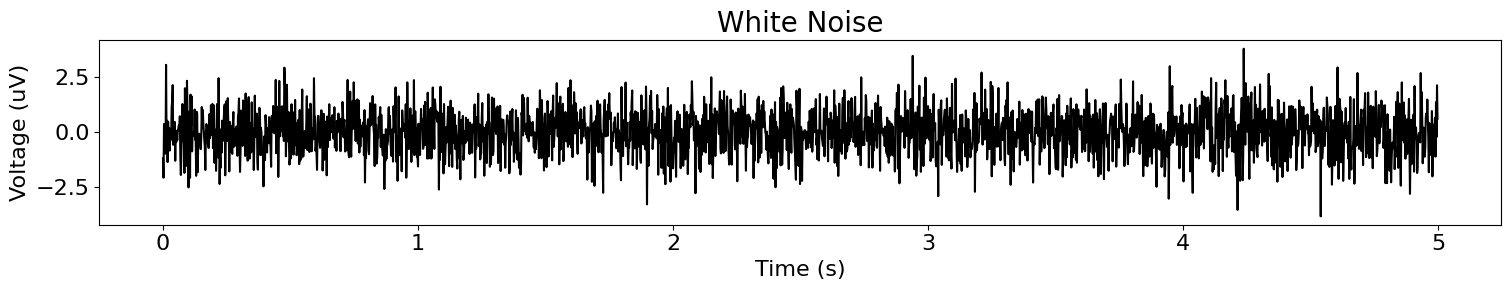

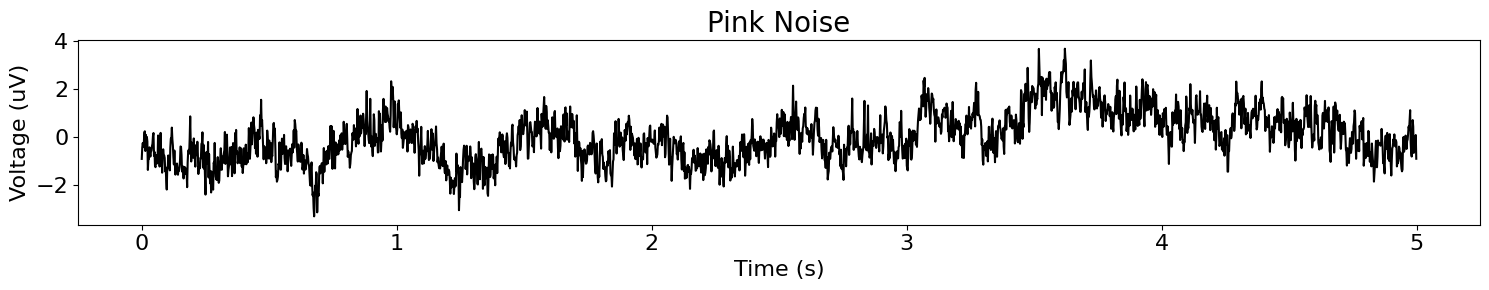

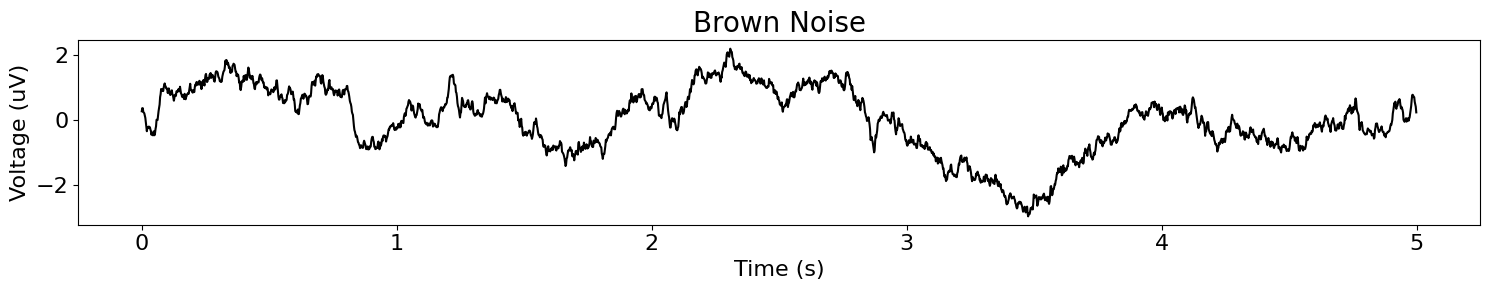

In [49]:
# Plot white noise time series
plot_time_series (times, white_signal, title = "White Noise")

# Plot pink noise time series
plot_time_series (times, pink_signal, title = "Pink Noise")

# Plot brown noise time series
plot_time_series (times, brown_signal, title = "Brown Noise")

**Comparison**
- White Noise - random
- Pink Noise - smoother than White Noise
- Brown Noise - smoother than Pink Noise

### Power Spectra

In [21]:
# Compute white, pink and brown power spectras
w_freqs, w_powers = compute_spectrum_welch(white_signal, s_rate)
p_freqs, p_powers = compute_spectrum_welch(pink_signal, s_rate)
b_freqs, b_powers = compute_spectrum_welch(brown_signal, s_rate)

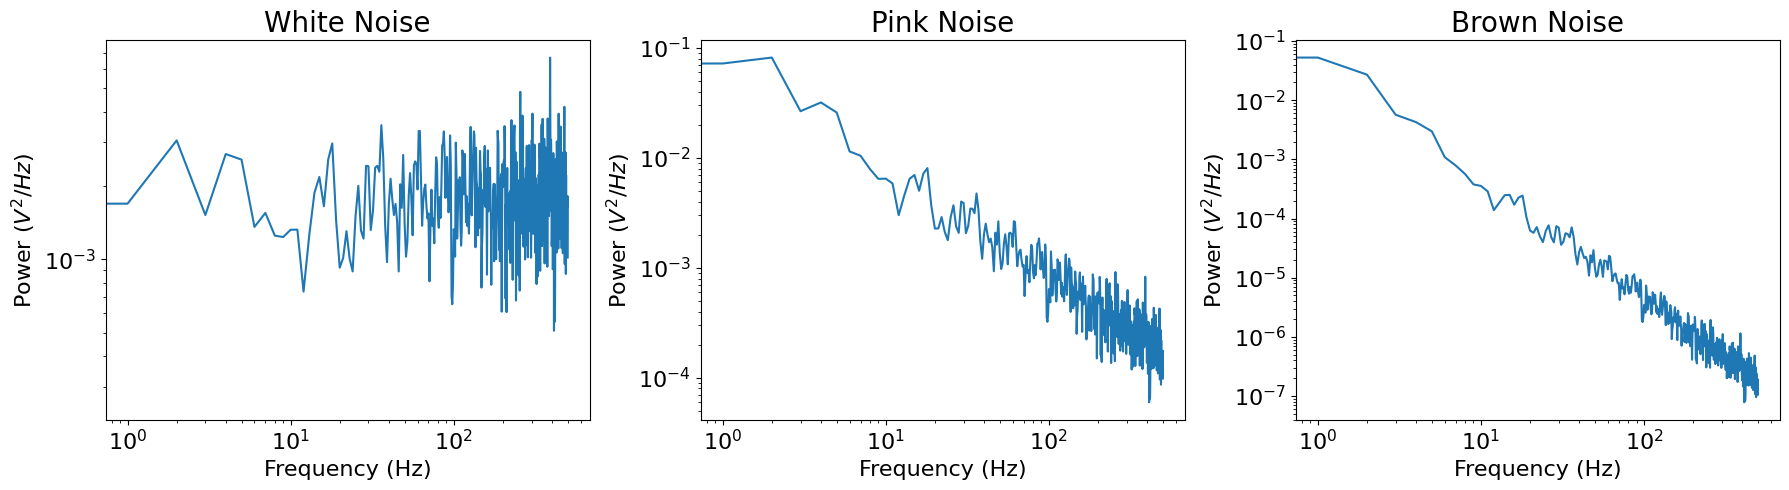

In [87]:
# Visualise white, pink and brown power spectras - log-log scale
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))
plot_power_spectra(w_freqs, w_powers, title = "White Noise", ax=ax1)
plot_power_spectra(p_freqs, p_powers, title = "Pink Noise", ax=ax2)
plot_power_spectra(b_freqs, b_powers, title = "Brown Noise", ax=ax3)

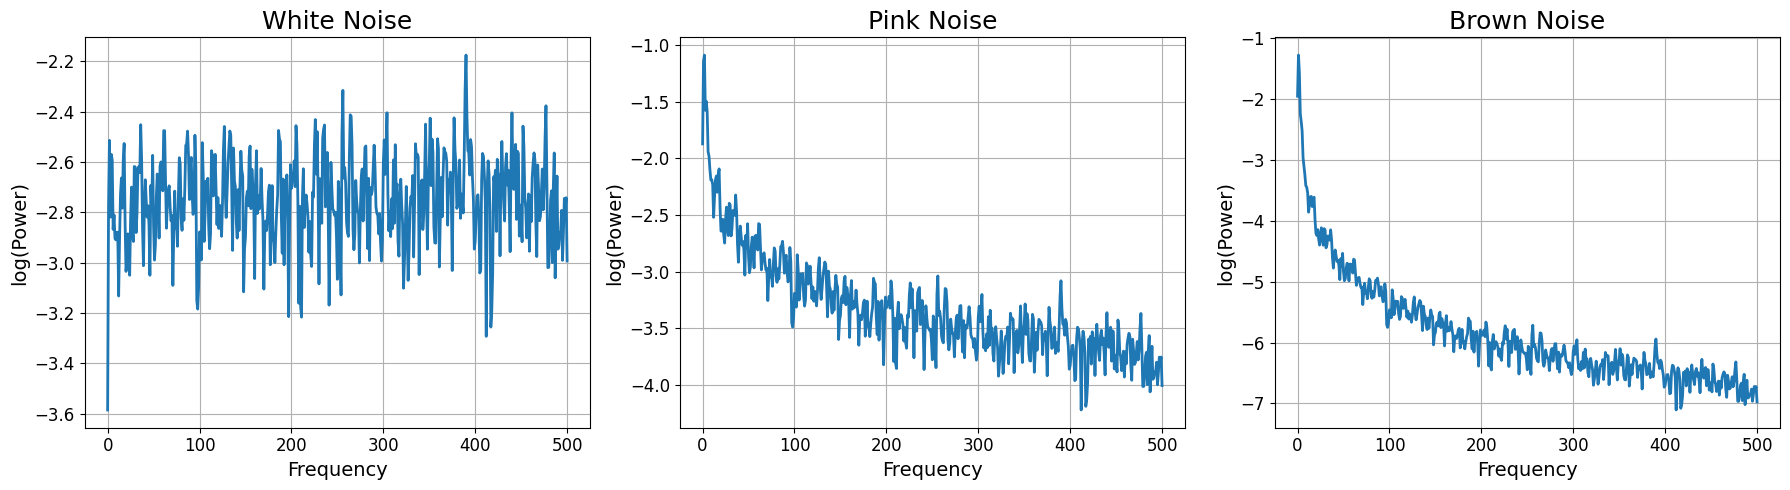

In [88]:
# Visualise white, pink and brown power spectras - frequency in linear scale
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))
plot_spectra(w_freqs, w_powers, log_powers=True, title = "White Noise", ax=ax1)
plot_spectra(p_freqs, p_powers, log_powers=True, title = "Pink Noise", ax=ax2)
plot_spectra(b_freqs, b_powers, log_powers=True, title = "Brown Noise", ax=ax3)

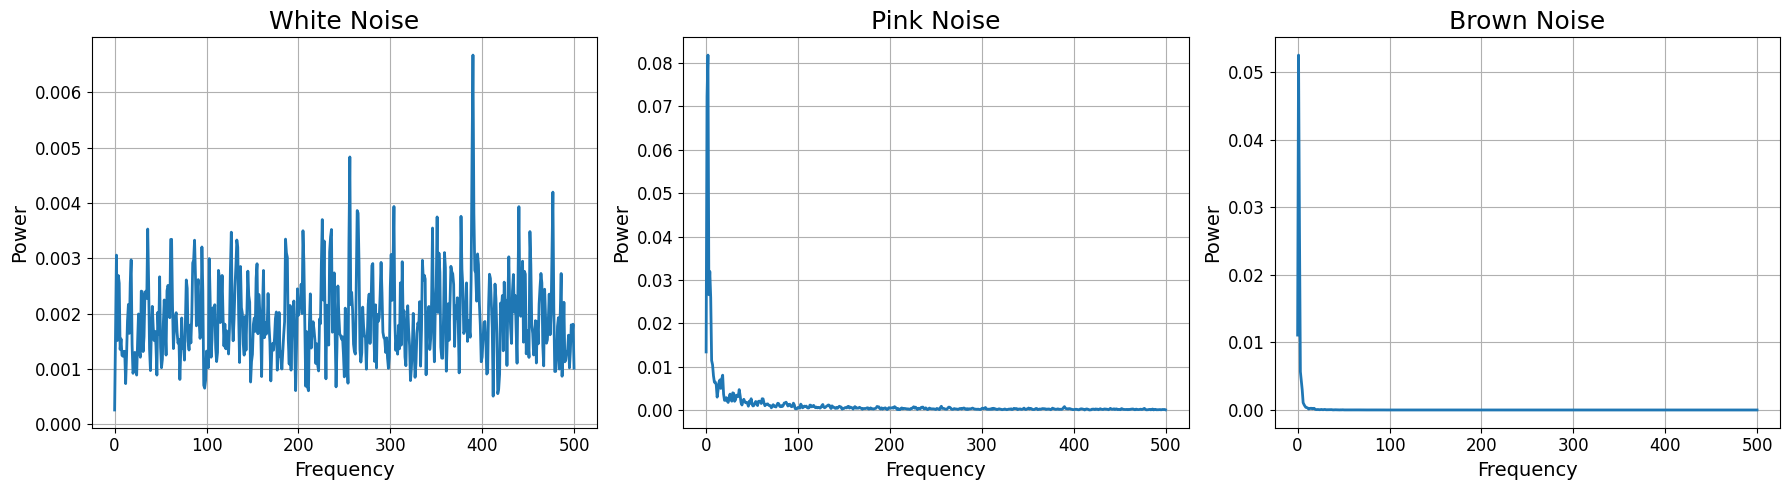

In [89]:
# Visualise white, pink and brown power spectras - linear scale
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))
plot_spectra(w_freqs, w_powers, title = "White Noise", ax=ax1)
plot_spectra(p_freqs, p_powers, title = "Pink Noise", ax=ax2)
plot_spectra(b_freqs, b_powers, title = "Brown Noise", ax=ax3)

**Comparison**
- White Noise has equal power across all frequencies
- Pink and Brown Noise has higher power in lower frequencies

- When plotted in log form, Pink and Brown Noise have negative slopes
- When plotted in linear form, Pink and Brown Noise have a sharp peak at low frequencies and then flatten as power increases - happens more quickly in Brown Noise than Pink

### Spectral Model


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

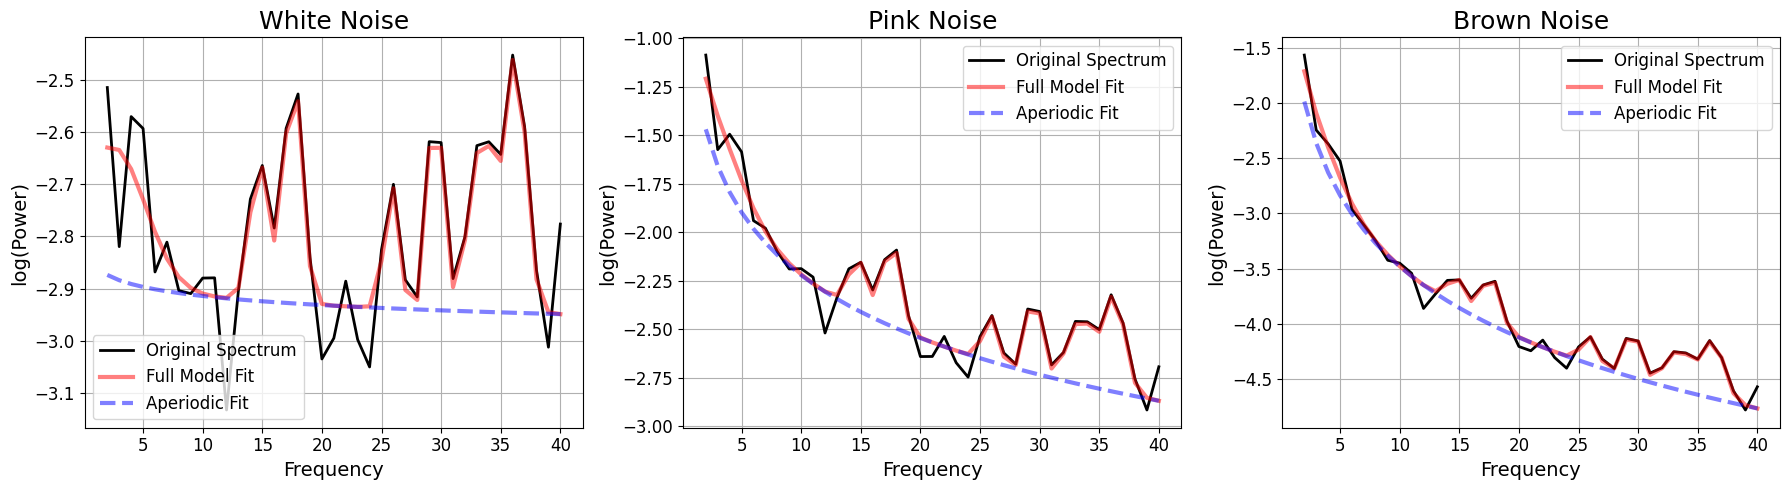

In [93]:
# Initialise and fit Spectral Modelto the power spectra for white noise
fm_w = SpectralModel()
fm_p = SpectralModel()
fm_b = SpectralModel()
freq_range = [2, 40]
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))
fm_w.report(w_freqs, w_powers, freq_range, title = "White Noise", ax=ax1)
fm_p.report(p_freqs, p_powers, freq_range, title = "Pink Noise", ax=ax2)
fm_b.report(b_freqs, b_powers, freq_range, title = "Brown Noise", ax=ax3)

print('Aperiodic parameters - White Noise: \n', fm_w.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Pink Noise: \n', fm_p.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Brown Noise: \n', fm_b.results.params.aperiodic.params, '\n')

## Sim Explores

Parameters to explore in the above simulations:
- what is the effect of different lengths of data on the PSDs & fit models
- what is the effect of different sampling rates on the PSDs & fit models

Parameters to explore in the spectral modeling:
- what are the different settings you can initialize the model with, how do they affect fitting

### Differing lengths of data


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

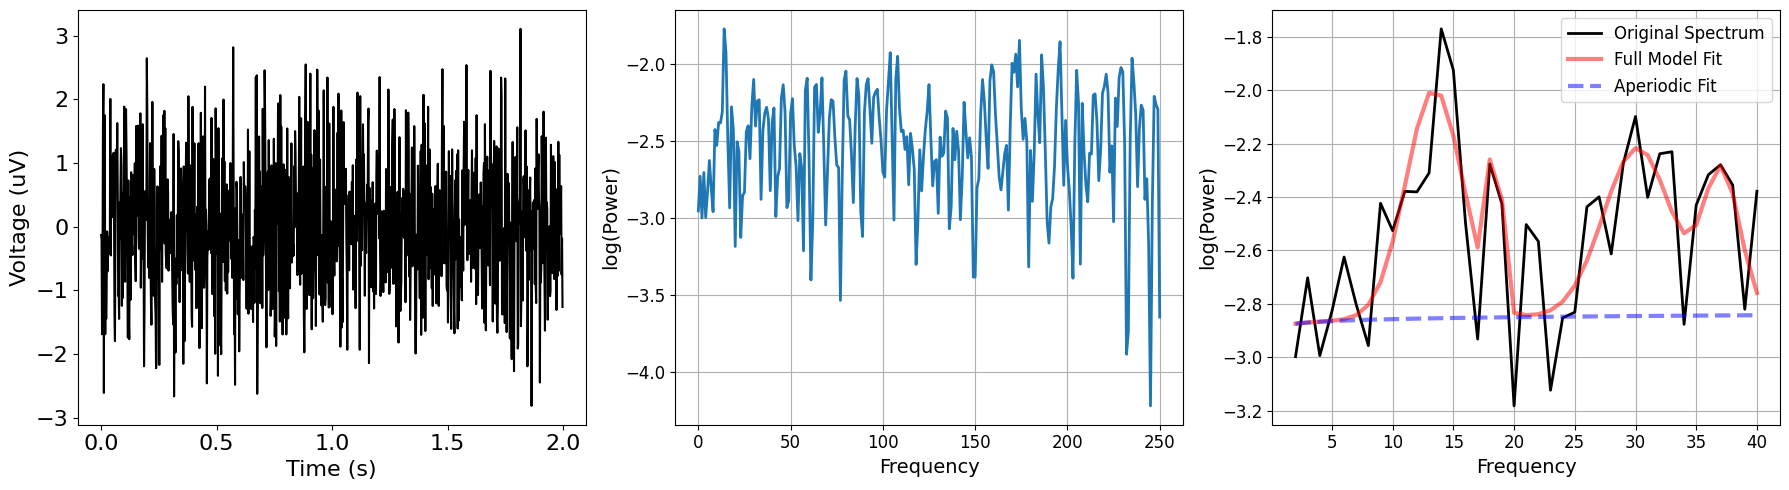

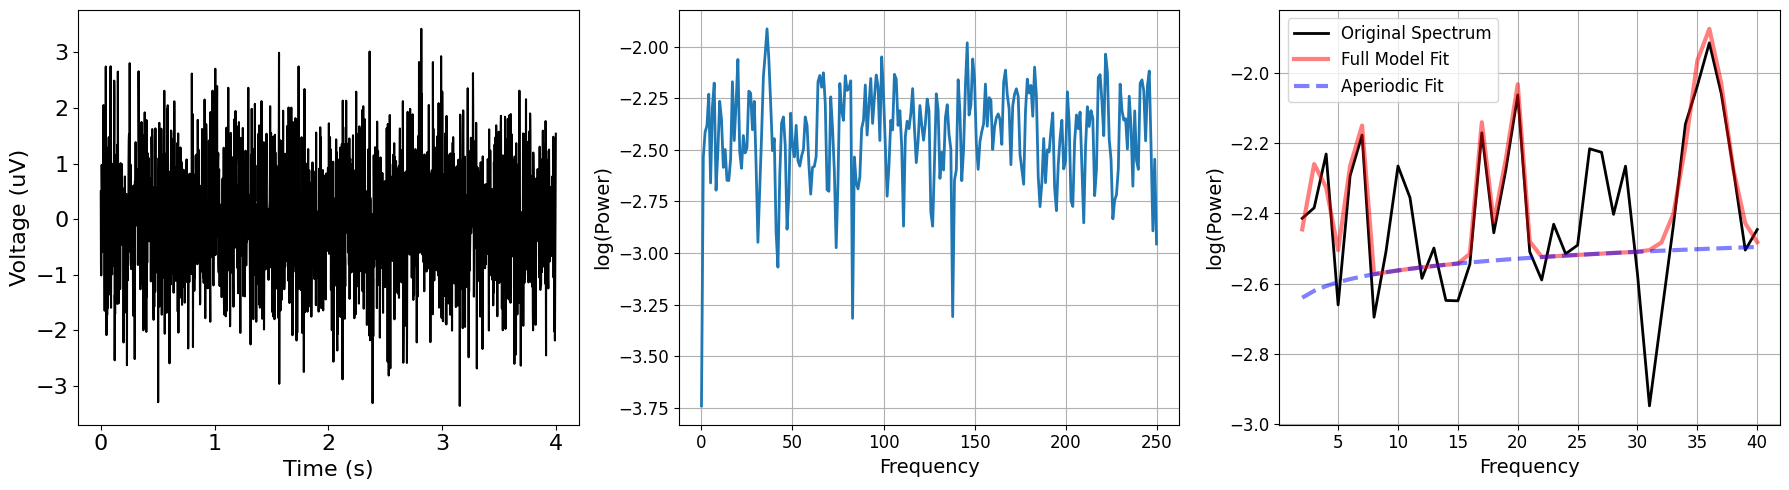

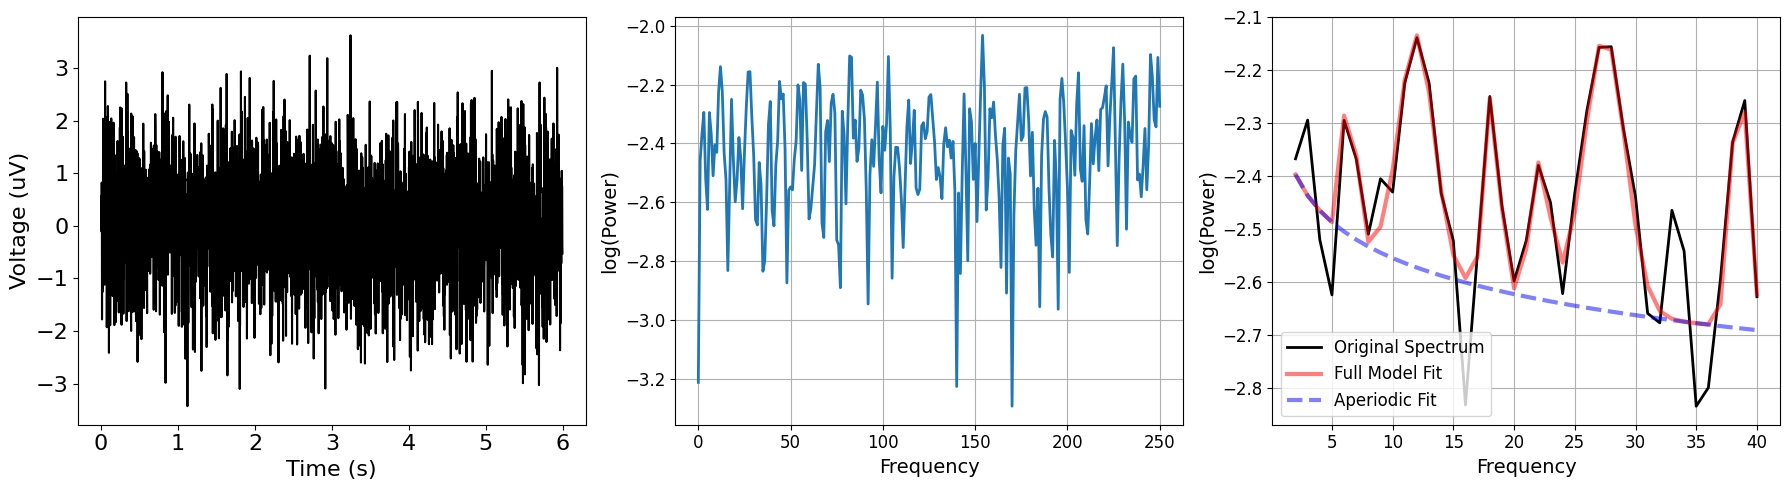

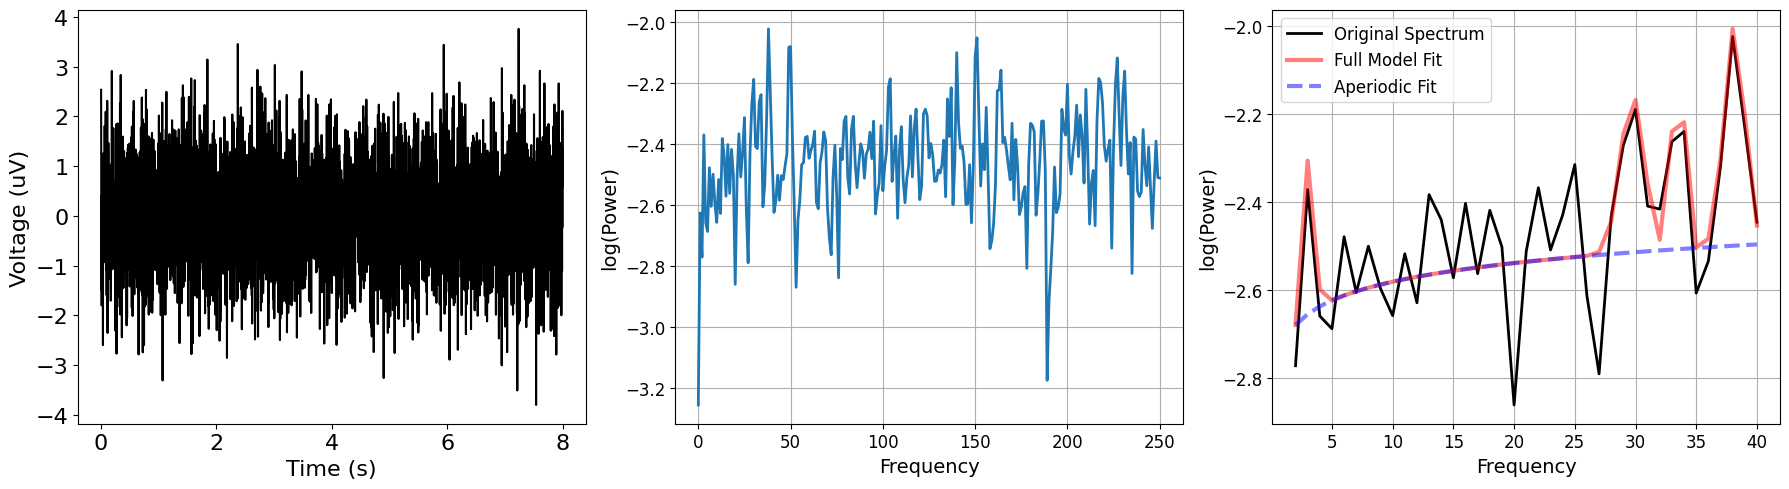

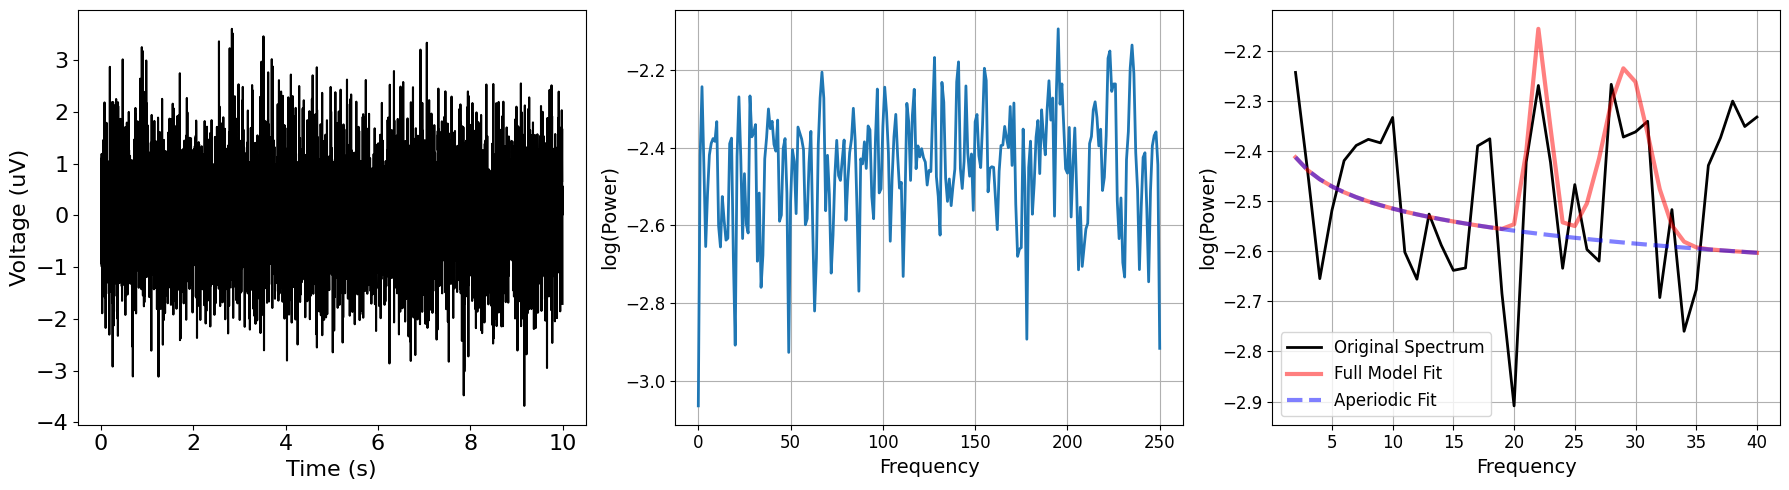

In [81]:
# Differing lengths of data - White Noise
set_random_seed(57)

# Shows White Noise time series, PSD and Spectral Model for data lengths of 2, 4, 6, 8 and 10 seconds
for n_seconds in range (2, 11, 2):
    s_rate = 500
    times = create_times(n_seconds, s_rate)
    n_points = len (times)

    white_signal = np.random.normal(0, 1, n_points)

    fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

    plot_time_series (times, white_signal, ax=ax1)
    
    w_freqs, w_powers = compute_spectrum_welch(white_signal, s_rate)

    plot_spectra(w_freqs, w_powers, log_powers=True, ax=ax2)

    fm = SpectralModel()
    freq_range = [2, 40]
    fm.report(w_freqs, w_powers, freq_range, ax=ax3)


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

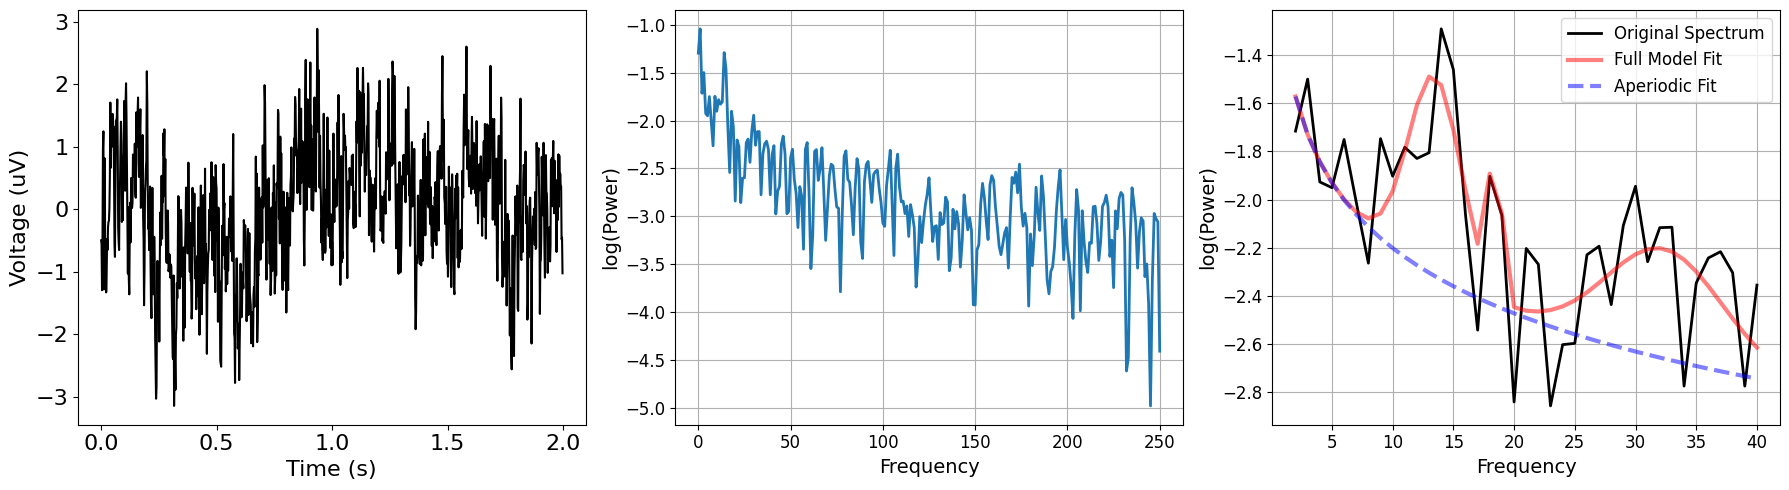

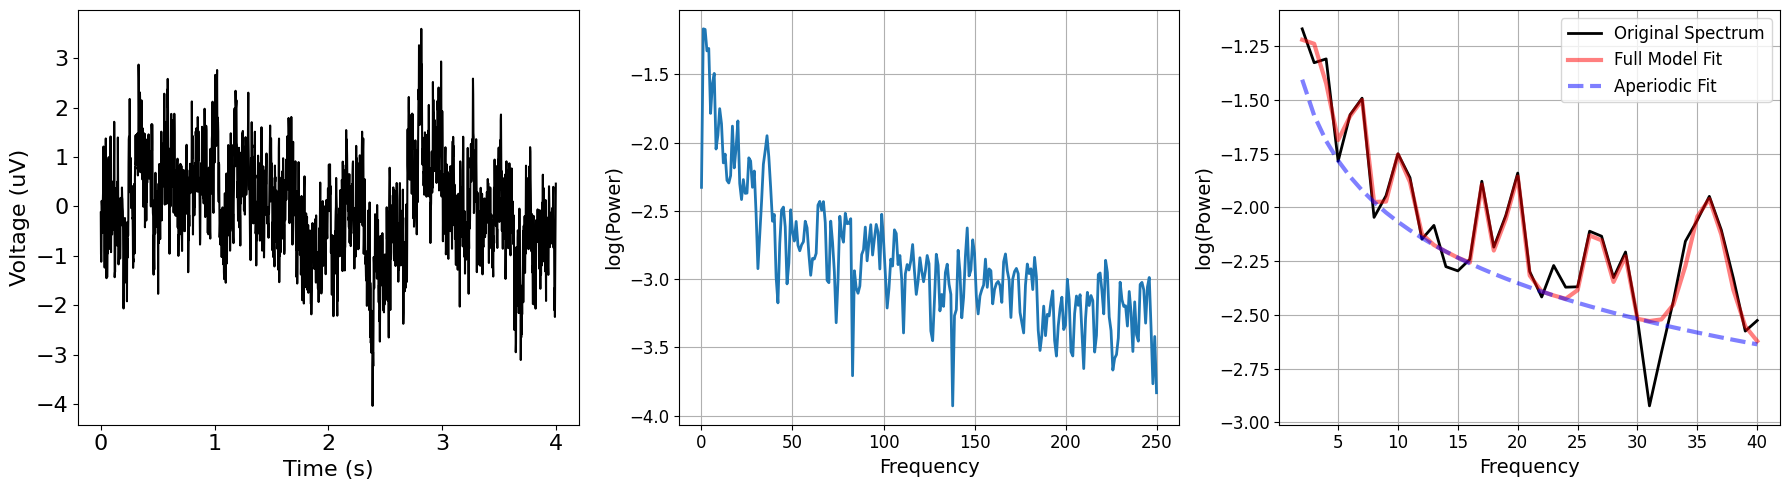

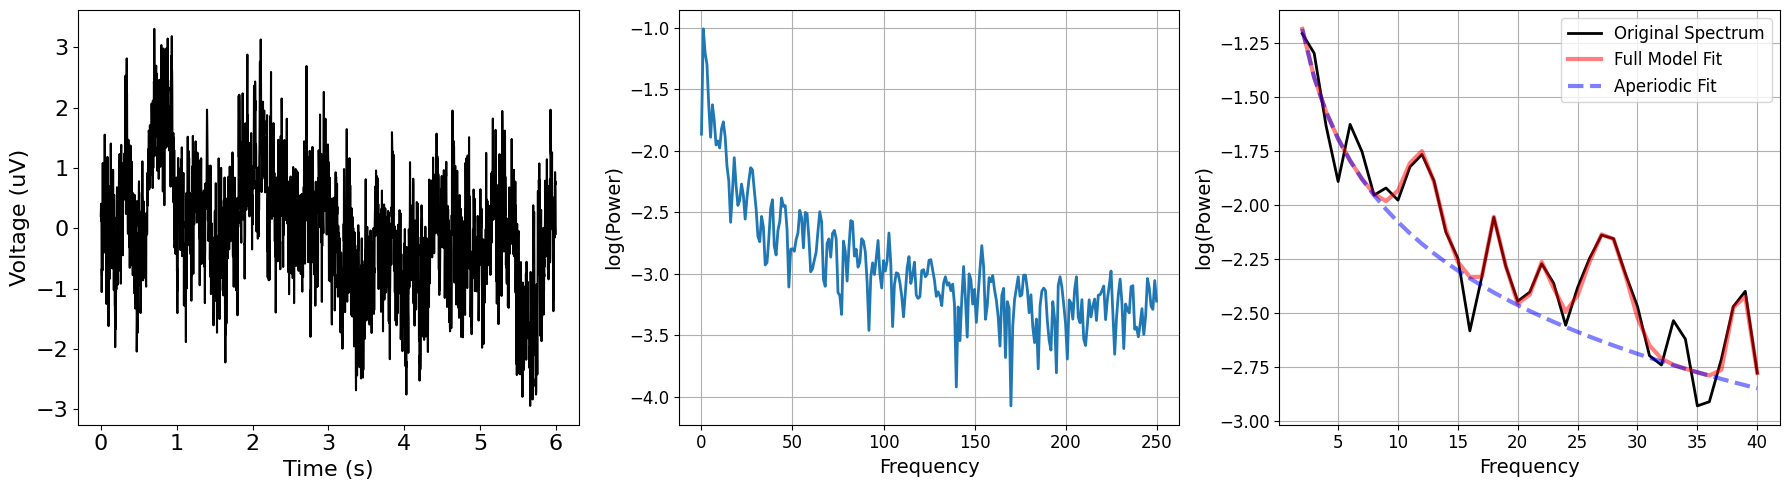

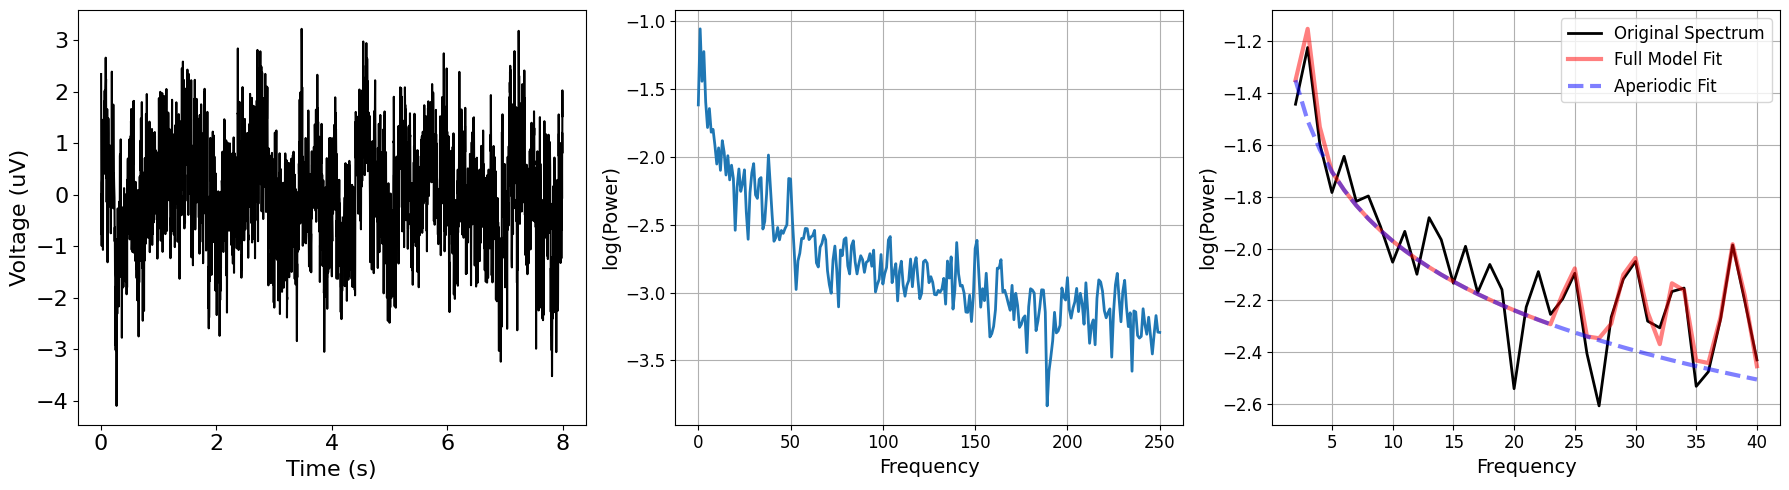

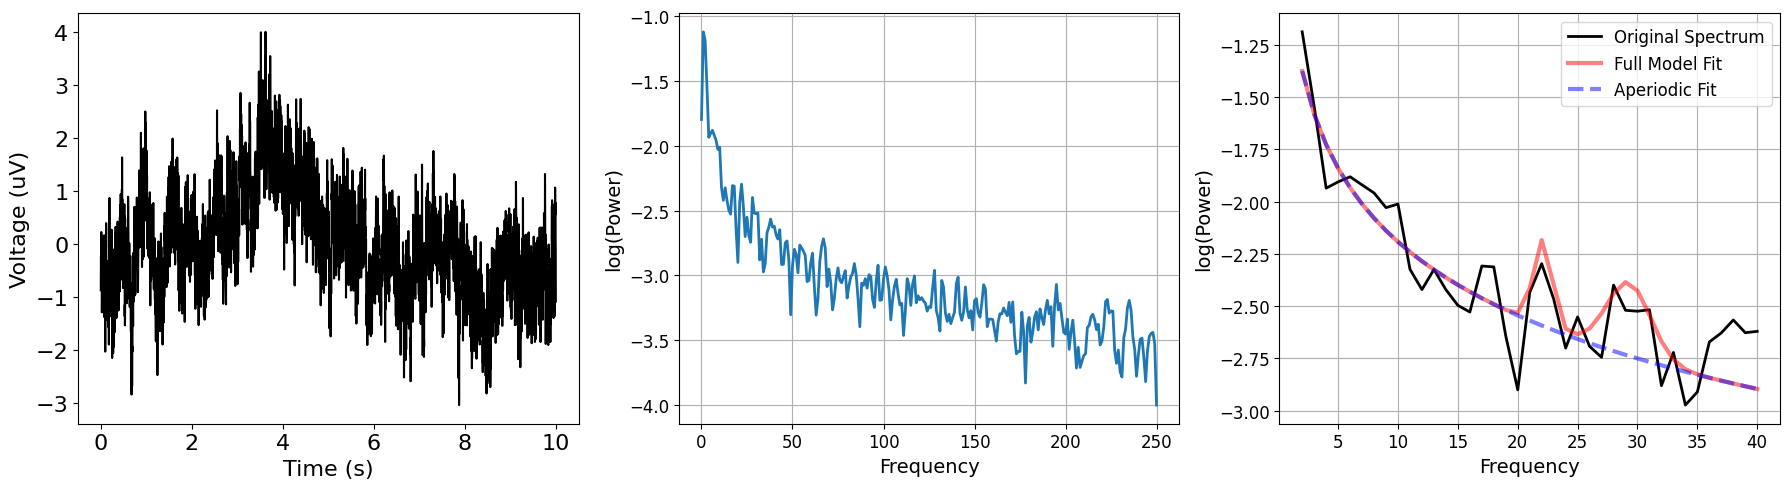

In [82]:
# Differing lengths of data - Pink Noise
set_random_seed(57)

# Shows Pink Noise time series, PSD and Spectral Model for data lengths of 2, 4, 6, 8 and 10 seconds
for n_seconds in range (2, 11, 2):
    s_rate = 500
    times = create_times(n_seconds, s_rate)
    n_points = len (times)

    pink_signal = sim_powerlaw(n_seconds, s_rate, exponent=-1)

    fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

    plot_time_series (times, pink_signal, ax=ax1)
    
    p_freqs, p_powers = compute_spectrum_welch(pink_signal, s_rate)

    plot_spectra(p_freqs, p_powers, log_powers=True, ax=ax2)

    fm = SpectralModel()
    freq_range = [2, 40]
    fm.report(p_freqs, p_powers, freq_range, ax=ax3)


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

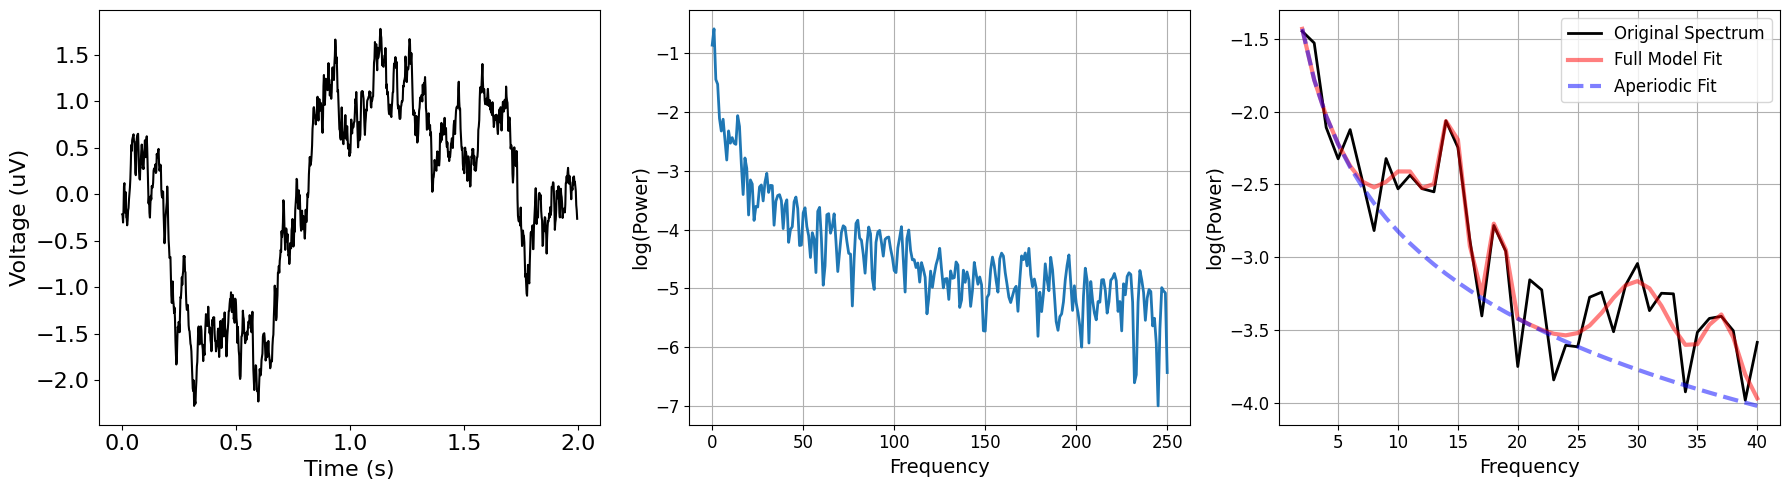

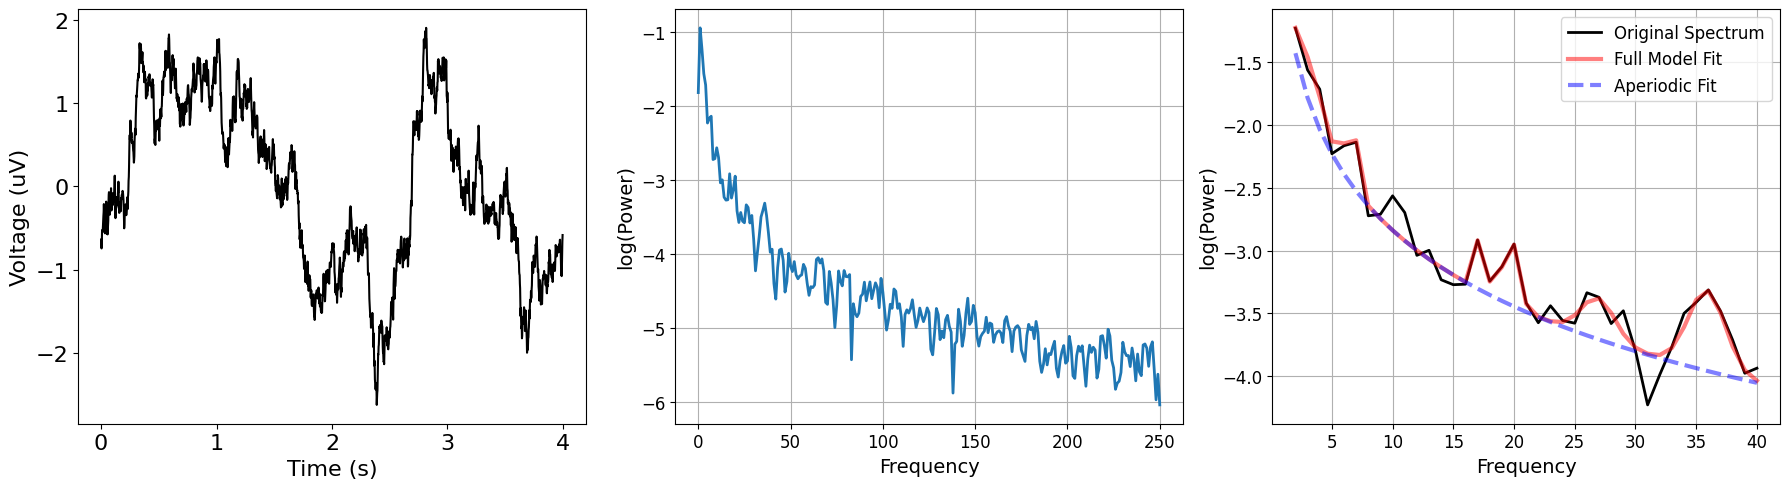

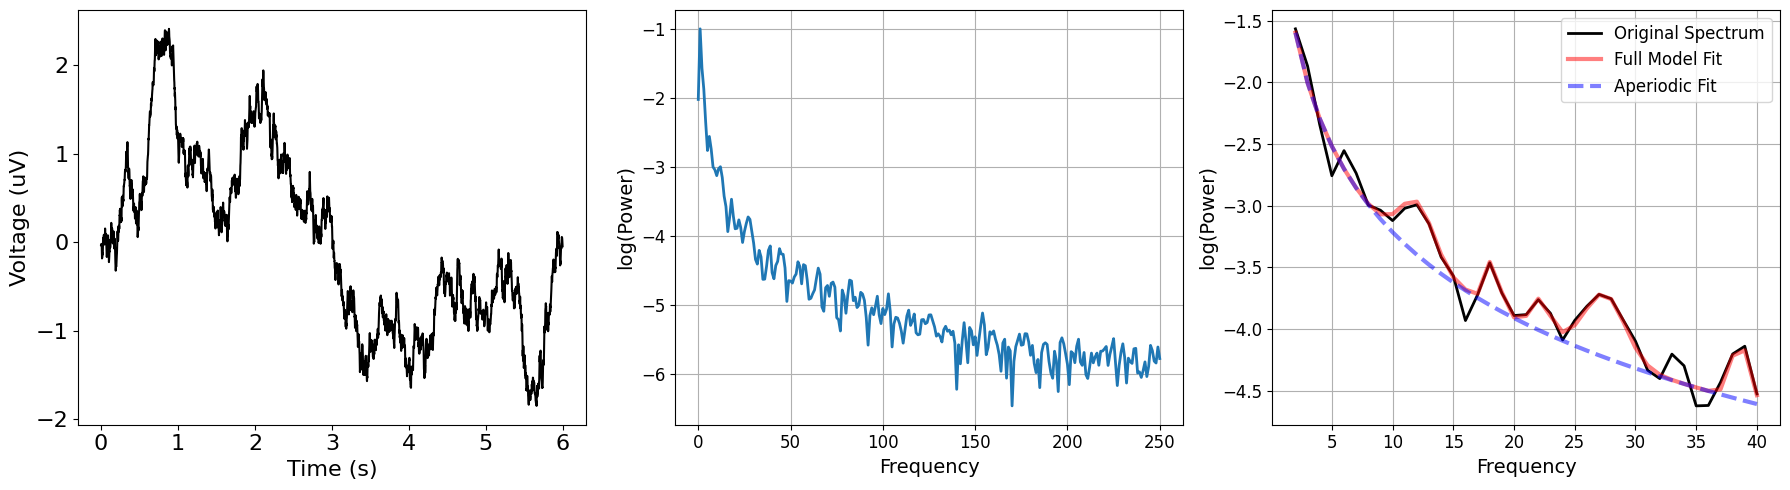

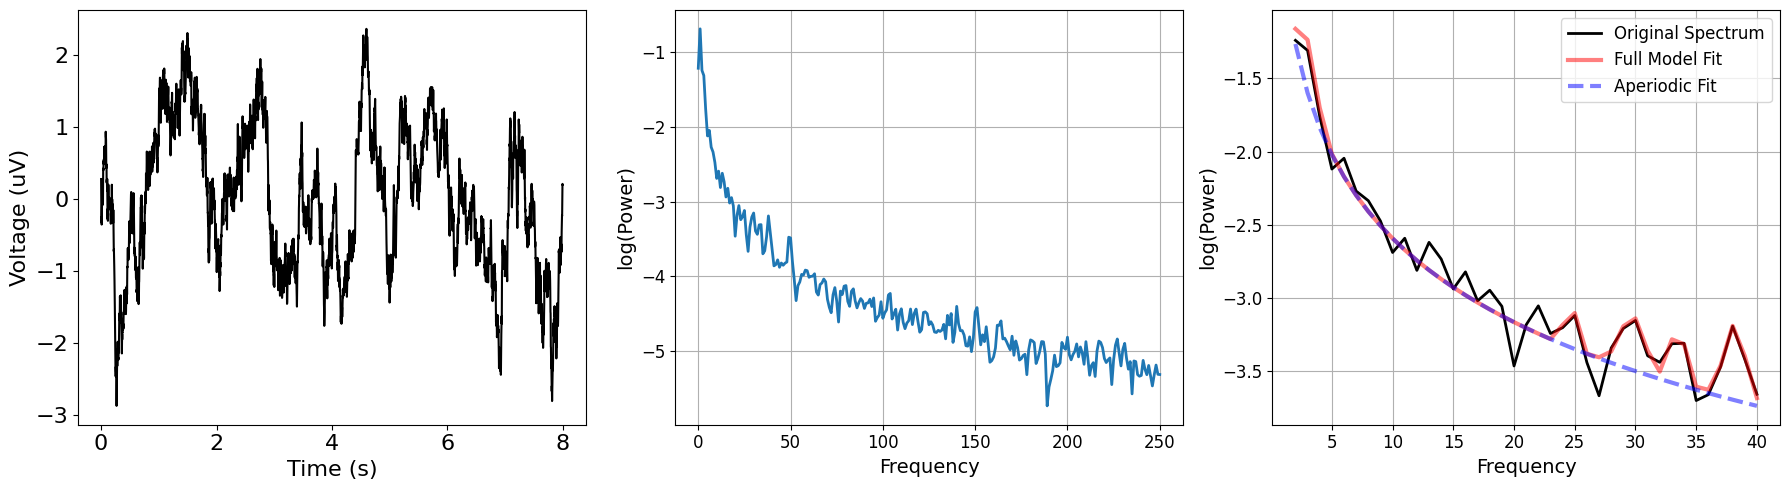

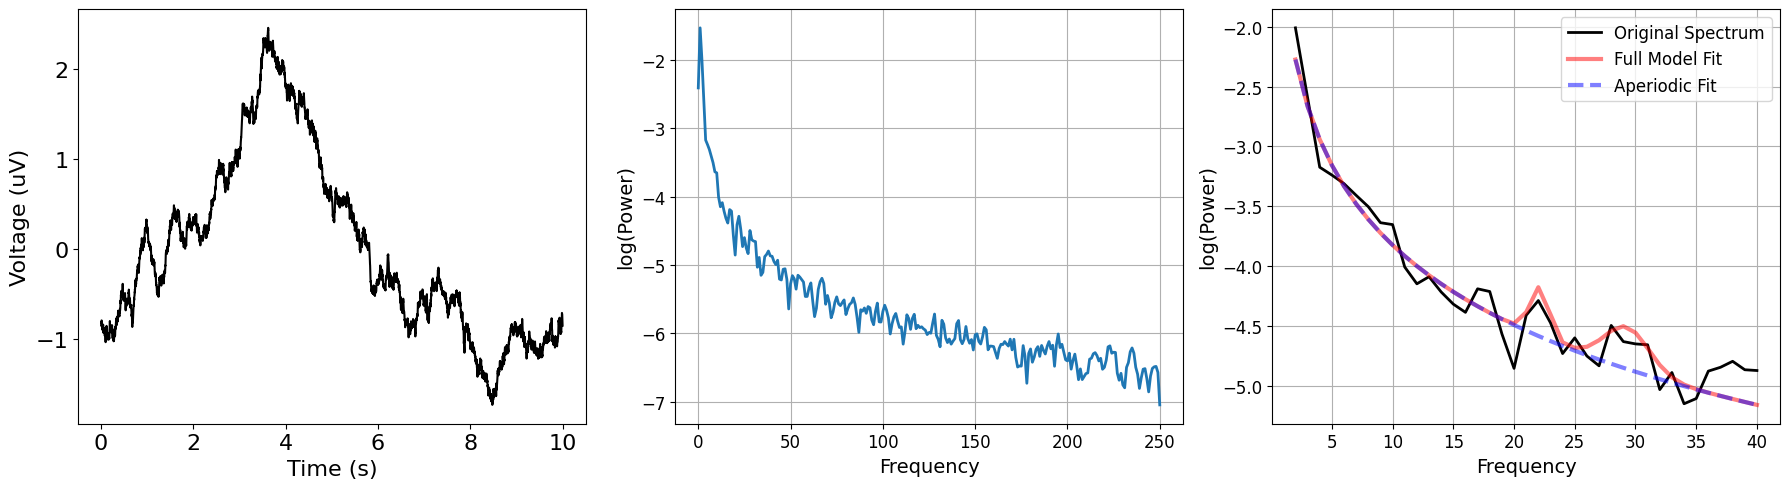

In [83]:
# Differing lengths of data - Brown Noise
set_random_seed(57)

# Shows Brown Noise time series, PSD and Spectral Model for data lengths of 2, 4, 6, 8 and 10 seconds
for n_seconds in range (2, 11, 2):
    s_rate = 500
    times = create_times(n_seconds, s_rate)
    n_points = len (times)

    brown_signal = sim_powerlaw(n_seconds, s_rate, exponent=-2)

    fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

    plot_time_series (times, brown_signal, ax=ax1)
    
    b_freqs, b_powers = compute_spectrum_welch(brown_signal, s_rate)

    plot_spectra(b_freqs, b_powers, log_powers=True, ax=ax2)

    fm = SpectralModel()
    freq_range = [2, 40]
    fm.report(b_freqs, b_powers, freq_range, ax=ax3)

### Differing sampling rates


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

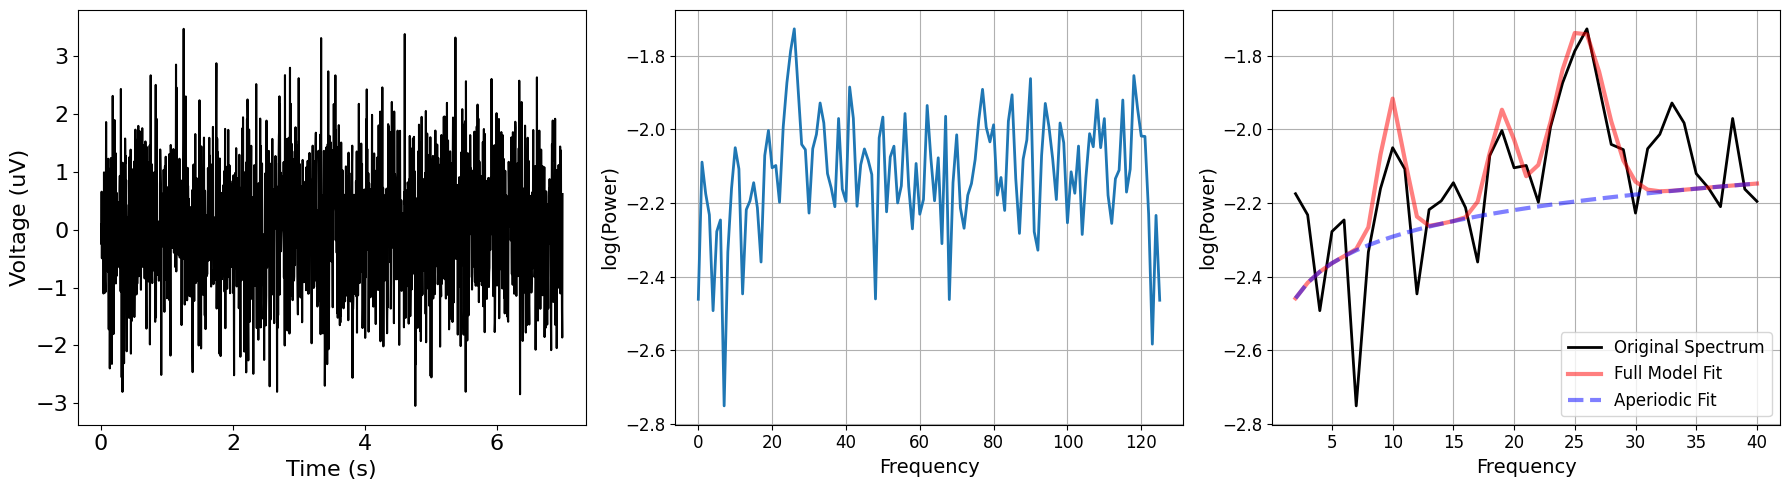

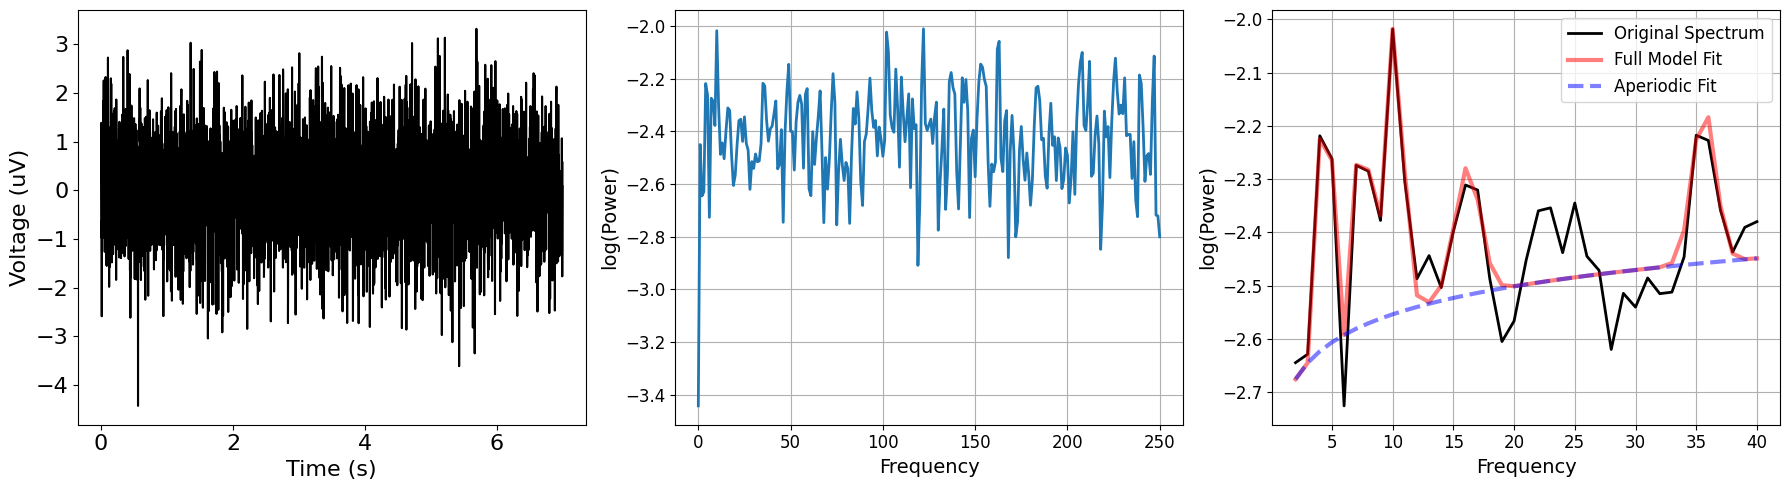

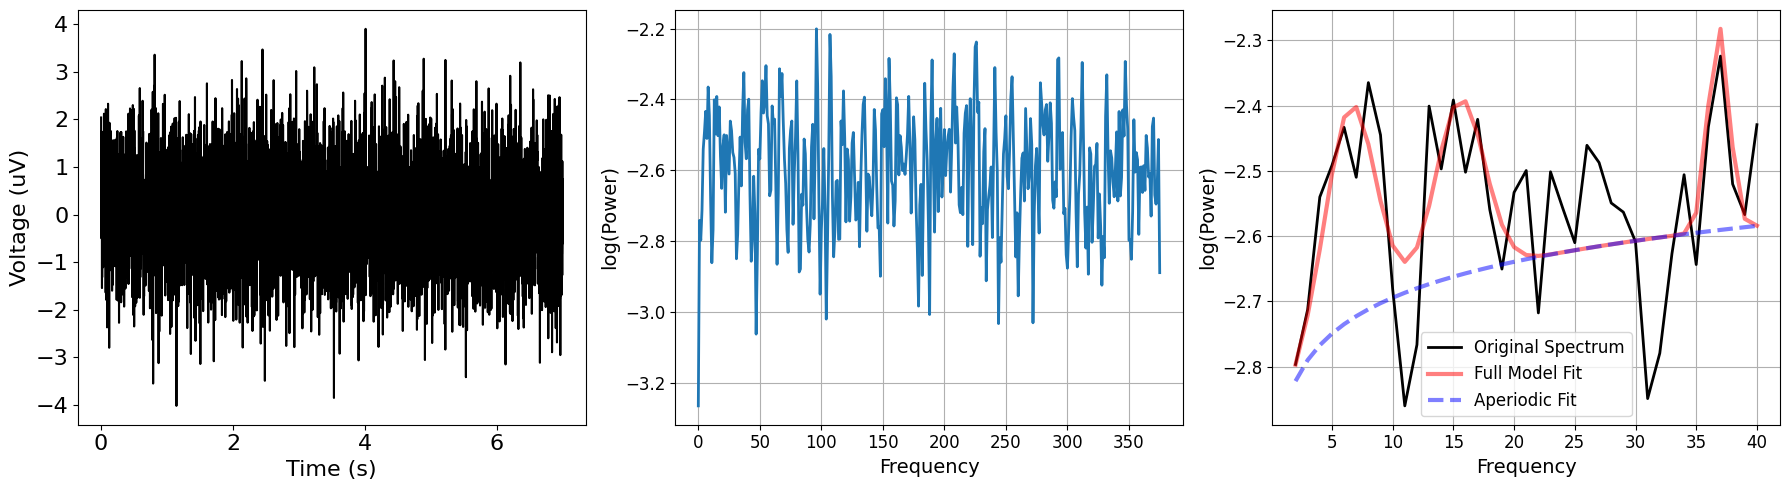

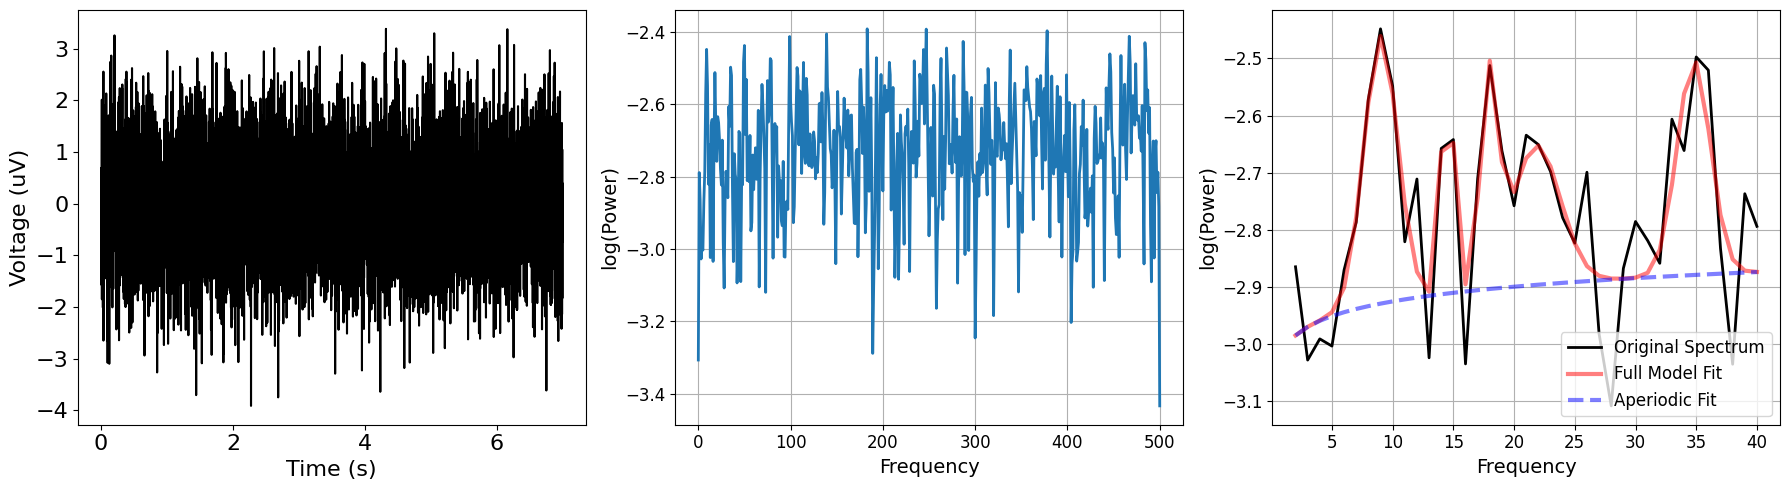

In [96]:
# Differing sampling rates - White Noise

# Shows White Noise time series, PSD and Spectral Model for sampling rates of 250, 500, 750 and 1000 Hz
for s_rate in range (250, 1001, 250):
    n_seconds = 7
    times = create_times(n_seconds, s_rate)
    n_points = len (times)

    white_signal = np.random.normal(0, 1, n_points)

    fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

    plot_time_series (times, white_signal, ax=ax1)
    
    w_freqs, w_powers = compute_spectrum_welch(white_signal, s_rate)

    plot_spectra(w_freqs, w_powers, log_powers=True, ax=ax2)

    fm = SpectralModel()
    freq_range = [2, 40]
    fm.report(w_freqs, w_powers, freq_range, ax=ax3)


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

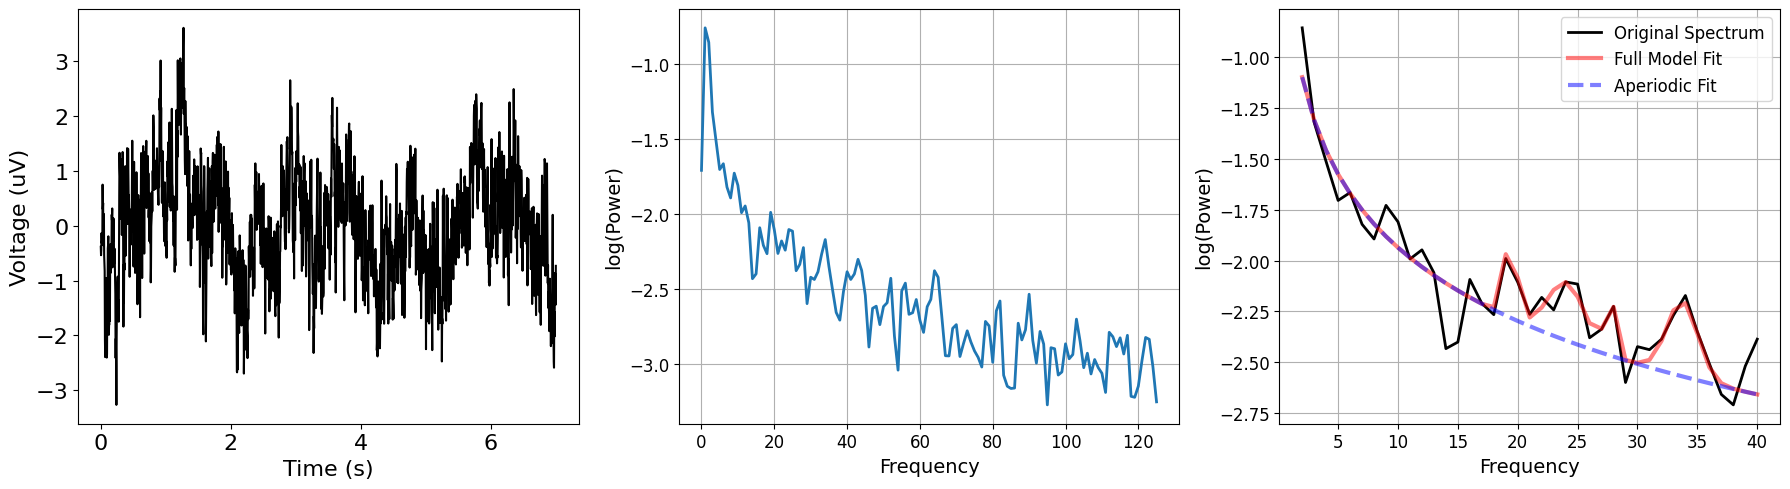

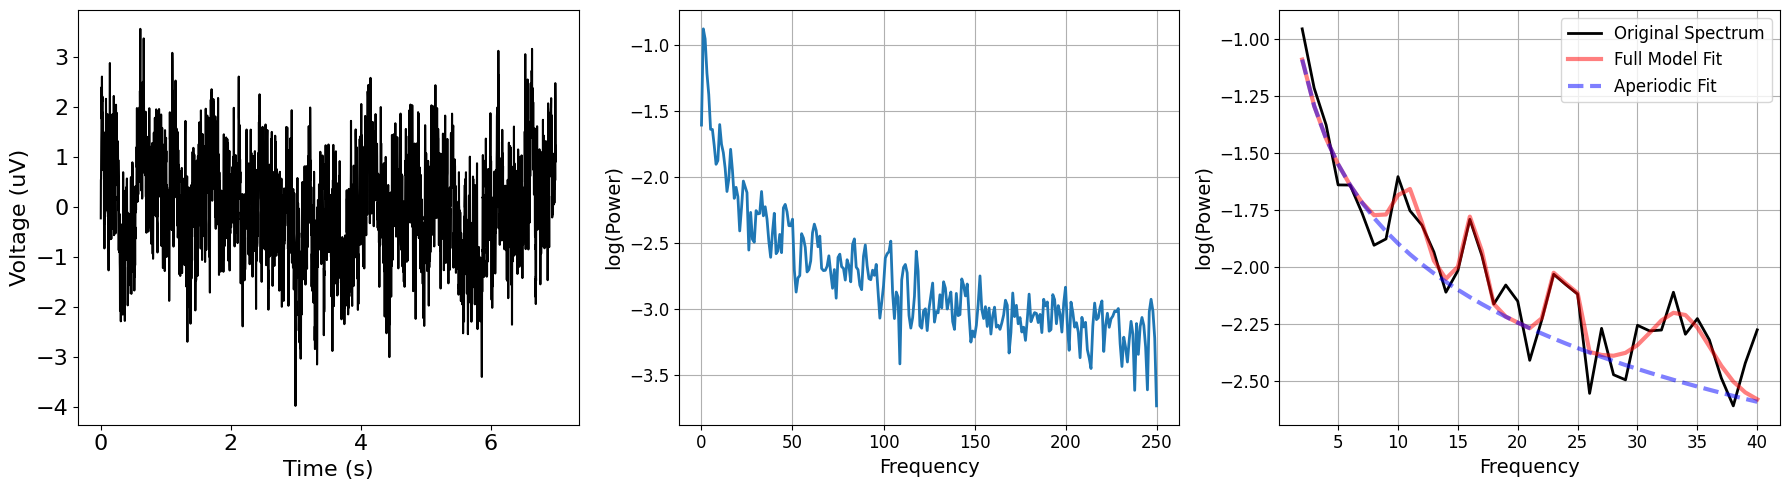

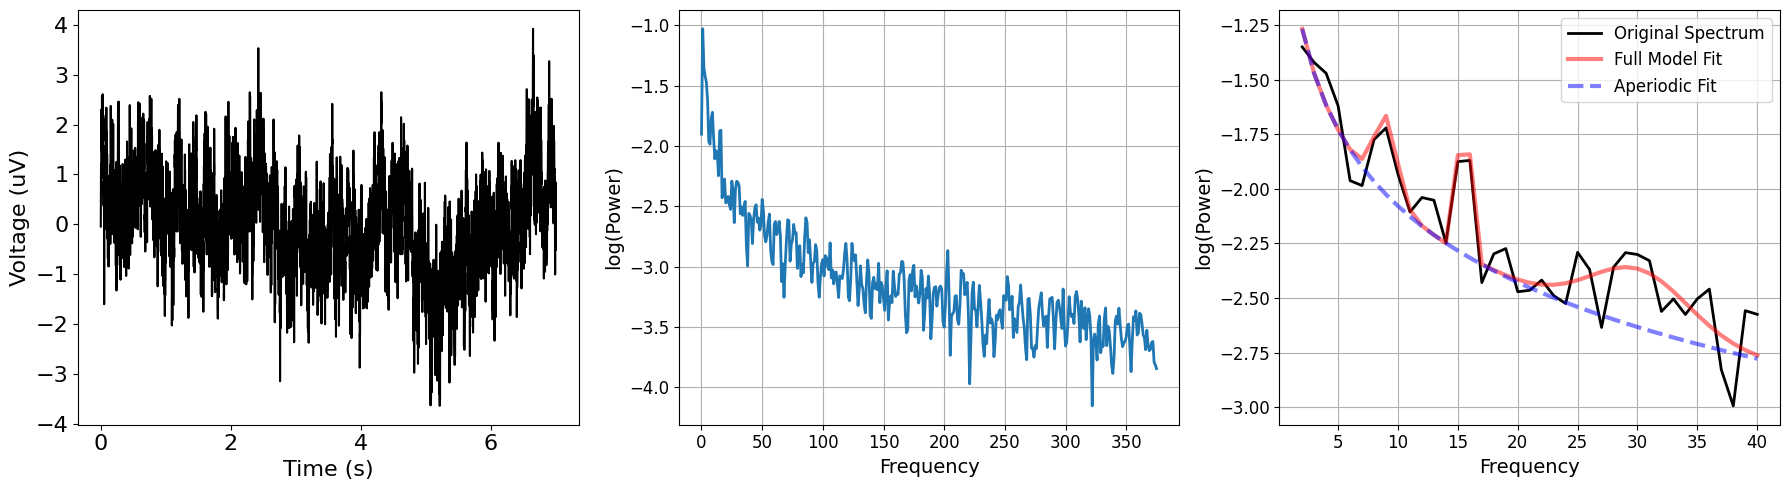

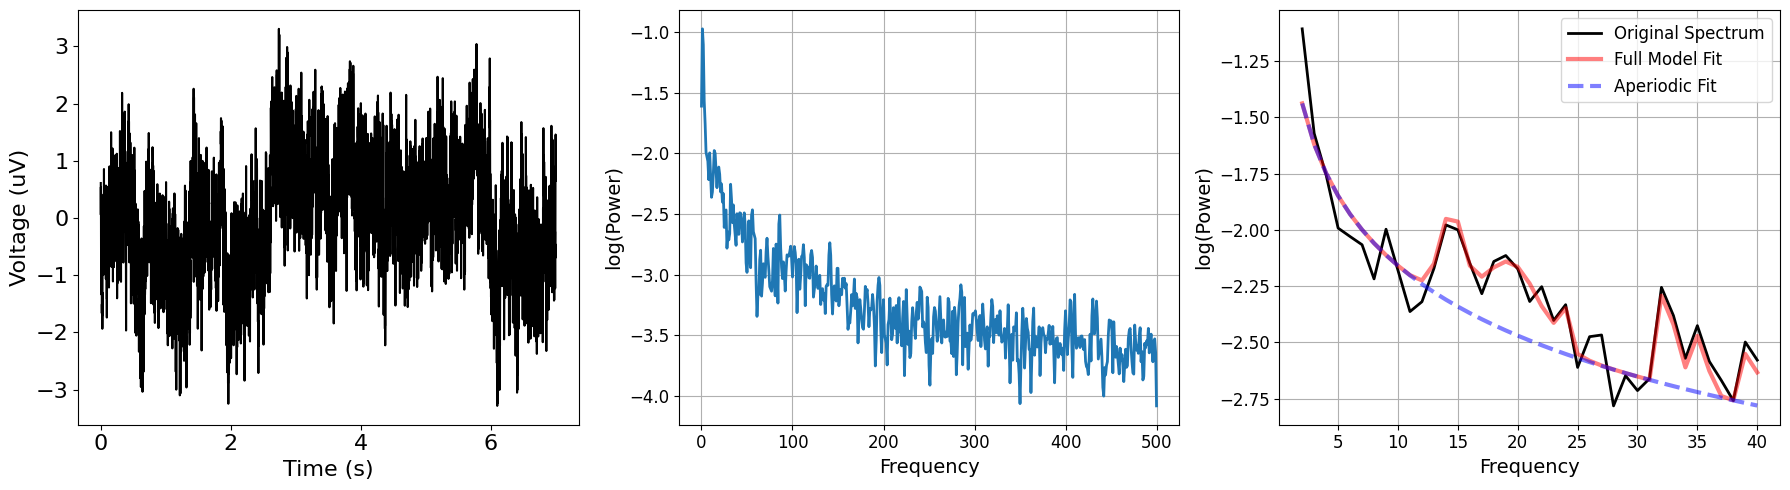

In [97]:
# Differing sampling rates - Pink Noise

# Shows Pink Noise time series, PSD and Spectral Model for sampling rates of 250, 500, 750 and 1000 Hz
for s_rate in range (250, 1001, 250):
    n_seconds = 7
    times = create_times(n_seconds, s_rate)
    n_points = len (times)

    pink_signal = sim_powerlaw(n_seconds, s_rate, exponent=-1)

    fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

    plot_time_series (times, pink_signal, ax=ax1)
    
    p_freqs, p_powers = compute_spectrum_welch(pink_signal, s_rate)

    plot_spectra(p_freqs, p_powers, log_powers=True, ax=ax2)

    fm = SpectralModel()
    freq_range = [2, 40]
    fm.report(p_freqs, p_powers, freq_range, ax=ax3)


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

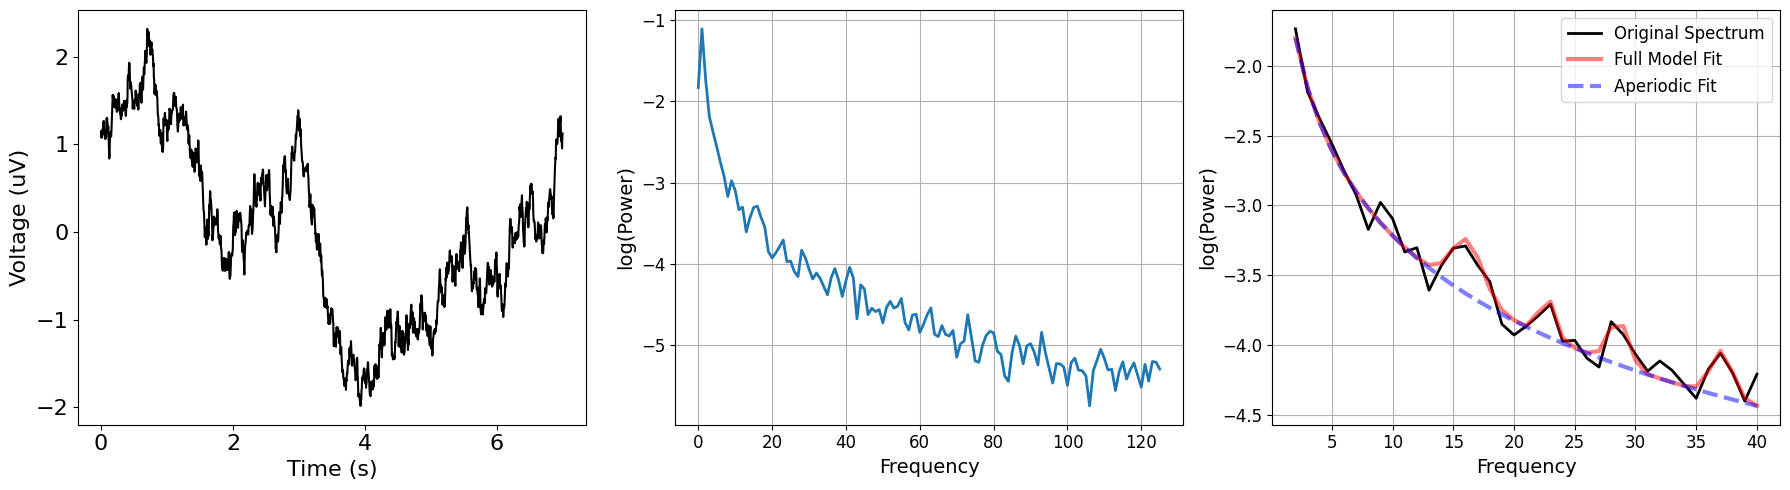

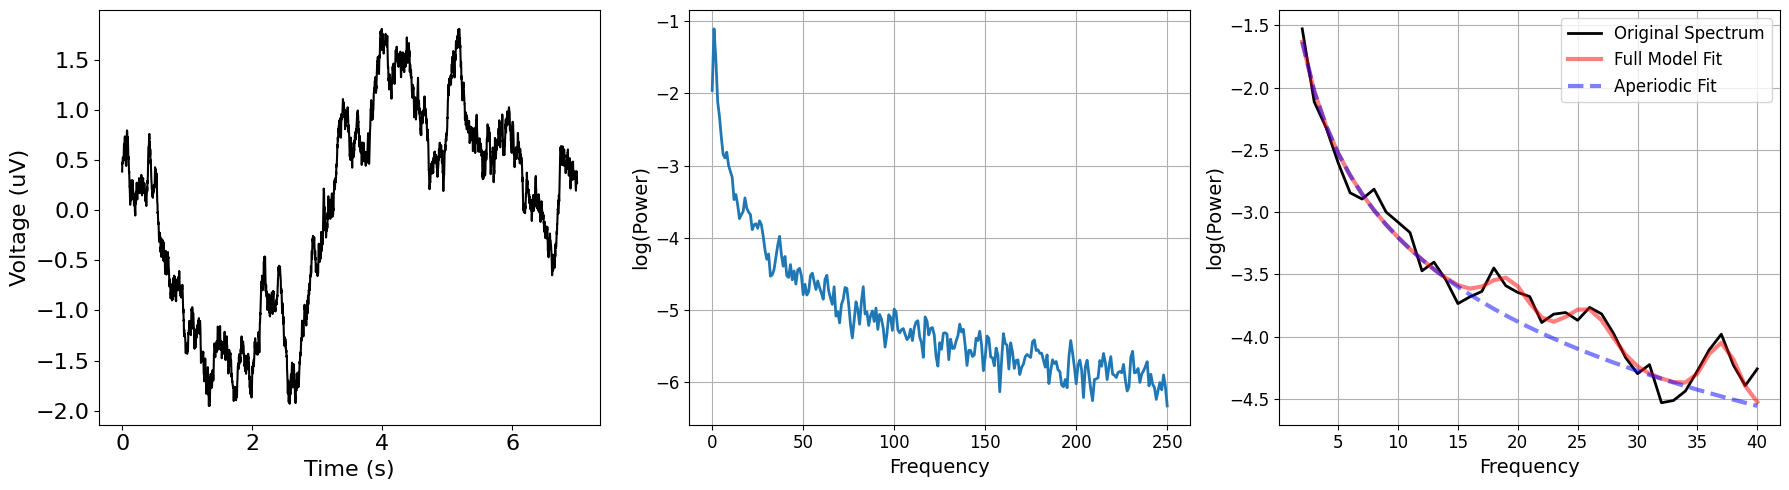

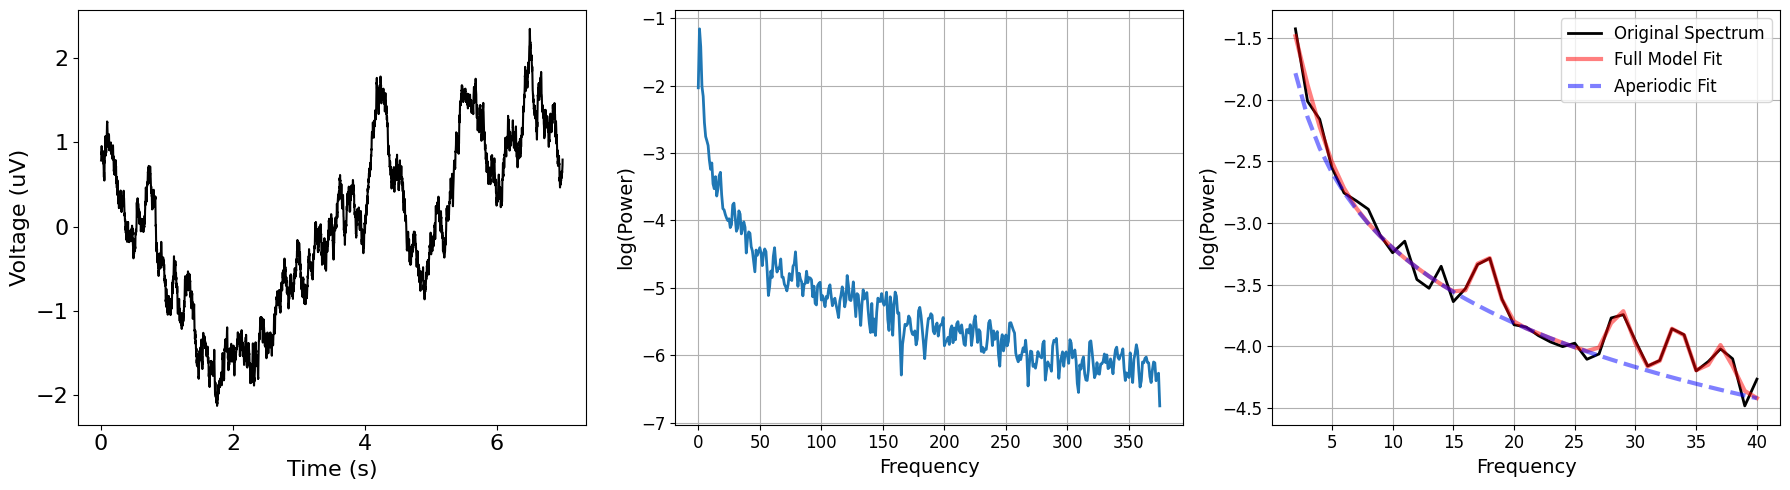

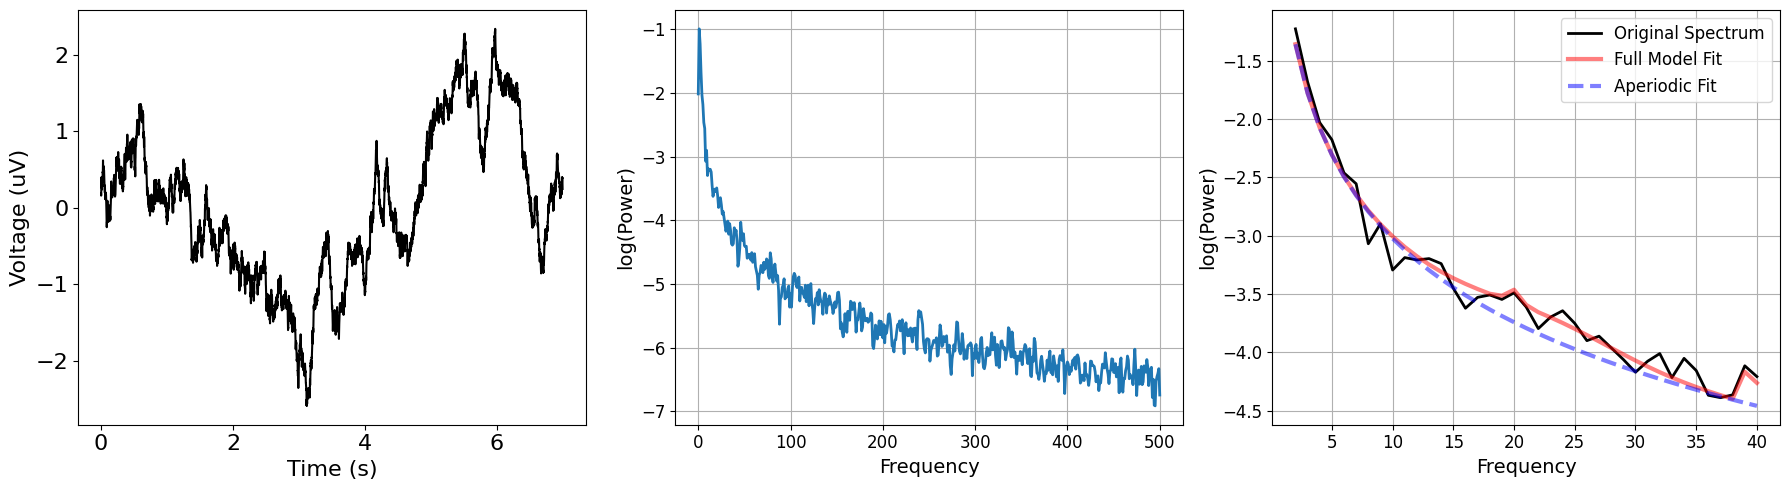

In [98]:
# Differing sampling - Brown Noise

# Shows Brown Noise time series, PSD and Spectral Model for sampling rates of 250, 500, 750 and 1000 Hz
for s_rate in range (250, 1001, 250):
    n_seconds = 7
    times = create_times(n_seconds, s_rate)
    n_points = len (times)

    brown_signal = sim_powerlaw(n_seconds, s_rate, exponent=-2)

    fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

    plot_time_series (times, brown_signal, ax=ax1)
    
    b_freqs, b_powers = compute_spectrum_welch(brown_signal, s_rate)

    plot_spectra(b_freqs, b_powers, log_powers=True, ax=ax2)

    fm = SpectralModel()
    freq_range = [2, 40]
    fm.report(b_freqs, b_powers, freq_range, ax=ax3)

### Differing spectral model initialisation settings

#### Simulation settings

In [100]:
# Simulation settings
n_seconds = 6 # Number of seconds
s_rate = 750 # Sampling rate

times = create_times(n_seconds, s_rate)
n_points = len(times)

# Simulate time series signals
white_signal = np.random.normal(0, 1, n_points)
pink_signal = sim_powerlaw(n_seconds, s_rate, exponent=-1)
brown_signal = sim_powerlaw(n_seconds, s_rate, exponent=-2)

# Compute power spectra
w_freqs, w_powers = compute_spectrum_welch(white_signal, s_rate)
p_freqs, p_powers = compute_spectrum_welch(pink_signal, s_rate)
b_freqs, b_powers = compute_spectrum_welch(brown_signal, s_rate)

#### Aperiodic mode


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                                Aperiodic Parameters ('knee' mode)                                
                                     (offset, kne

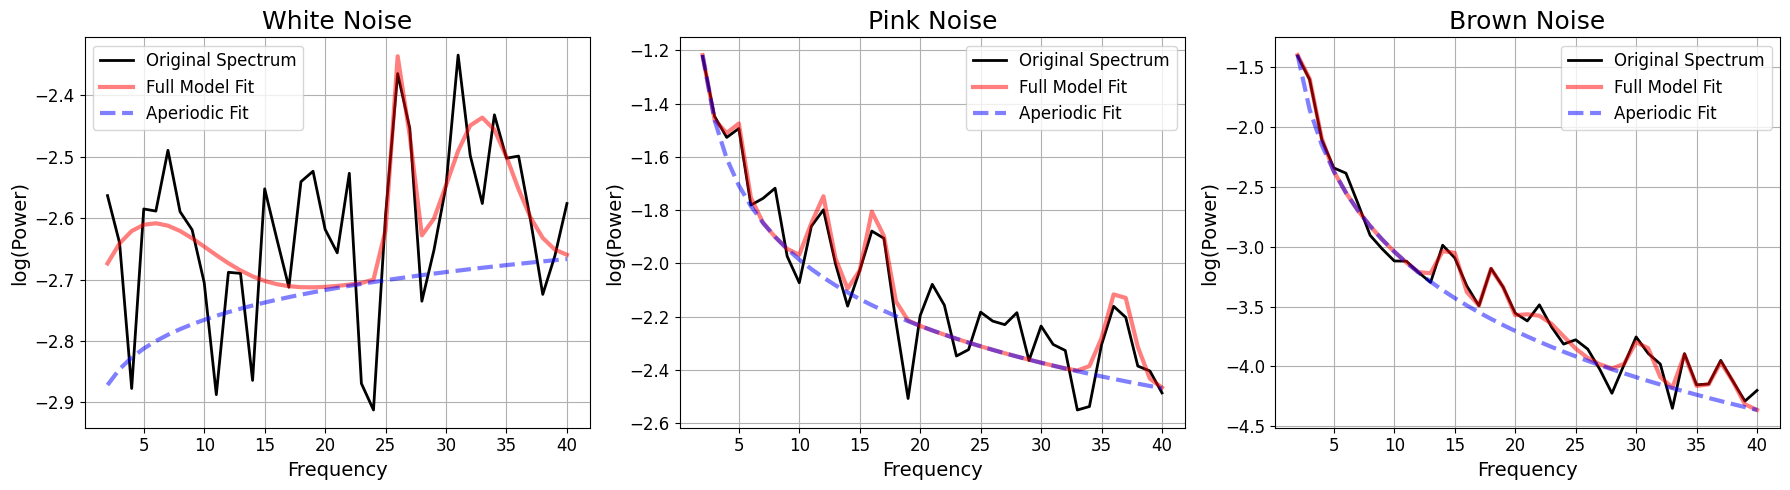

In [101]:
# Aperiodic mode = 'knee'

# Initialise and fit Spectral Modelto the power spectra
fm_w = SpectralModel(aperiodic_mode='knee')
fm_p = SpectralModel(aperiodic_mode='knee')
fm_b = SpectralModel(aperiodic_mode='knee')
freq_range = [2, 40]
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))
fm_w.report(w_freqs, w_powers, freq_range, title = "White Noise", ax=ax1)
fm_p.report(p_freqs, p_powers, freq_range, title = "Pink Noise", ax=ax2)
fm_b.report(b_freqs, b_powers, freq_range, title = "Brown Noise", ax=ax3)

print('Aperiodic parameters - White Noise: \n', fm_w.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Pink Noise: \n', fm_p.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Brown Noise: \n', fm_b.results.params.aperiodic.params, '\n')

#### Periodic mode


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

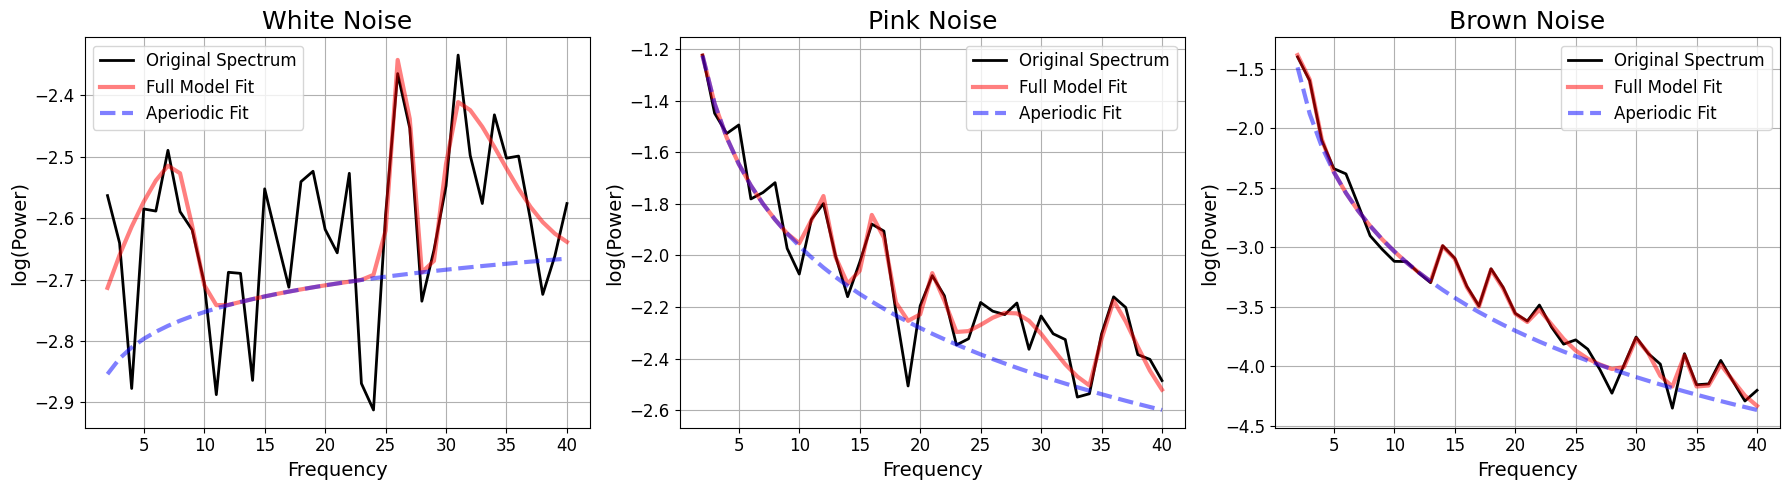

In [102]:
# Periodic mode = 'skewed_gaussian'

# Initialise and fit Spectral Modelto the power spectra
fm_w = SpectralModel(periodic_mode='skewed_gaussian')
fm_p = SpectralModel(periodic_mode='skewed_gaussian')
fm_b = SpectralModel(periodic_mode='skewed_gaussian')
freq_range = [2, 40]
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))
fm_w.report(w_freqs, w_powers, freq_range, title = "White Noise", ax=ax1)
fm_p.report(p_freqs, p_powers, freq_range, title = "Pink Noise", ax=ax2)
fm_b.report(b_freqs, b_powers, freq_range, title = "Brown Noise", ax=ax3)

print('Aperiodic parameters - White Noise: \n', fm_w.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Pink Noise: \n', fm_p.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Brown Noise: \n', fm_b.results.params.aperiodic.params, '\n')


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

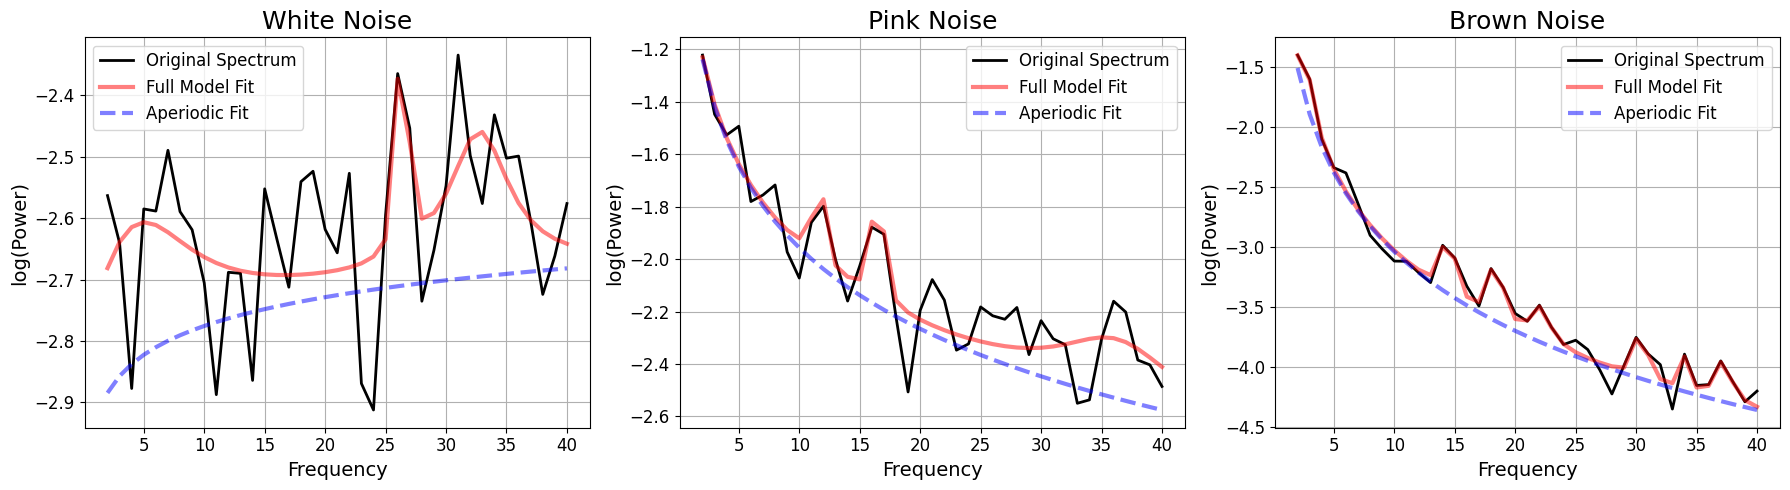

In [103]:
# Periodic mode = 'cauchy'

# Initialise and fit Spectral Modelto the power spectra
fm_w = SpectralModel(periodic_mode='cauchy')
fm_p = SpectralModel(periodic_mode='cauchy')
fm_b = SpectralModel(periodic_mode='cauchy')
freq_range = [2, 40]
fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))
fm_w.report(w_freqs, w_powers, freq_range, title = "White Noise", ax=ax1)
fm_p.report(p_freqs, p_powers, freq_range, title = "Pink Noise", ax=ax2)
fm_b.report(b_freqs, b_powers, freq_range, title = "Brown Noise", ax=ax3)

print('Aperiodic parameters - White Noise: \n', fm_w.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Pink Noise: \n', fm_p.results.params.aperiodic.params, '\n')
print('Aperiodic parameters - Brown Noise: \n', fm_b.results.params.aperiodic.params, '\n')

#### Max peaks


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

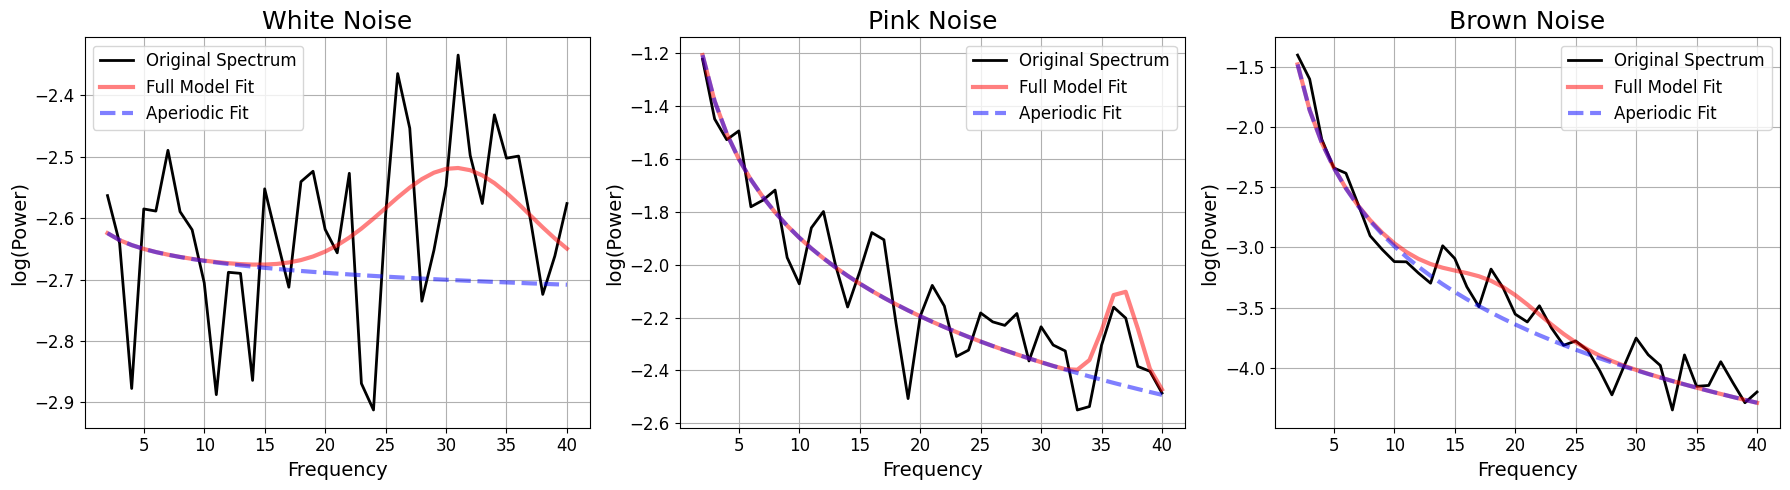

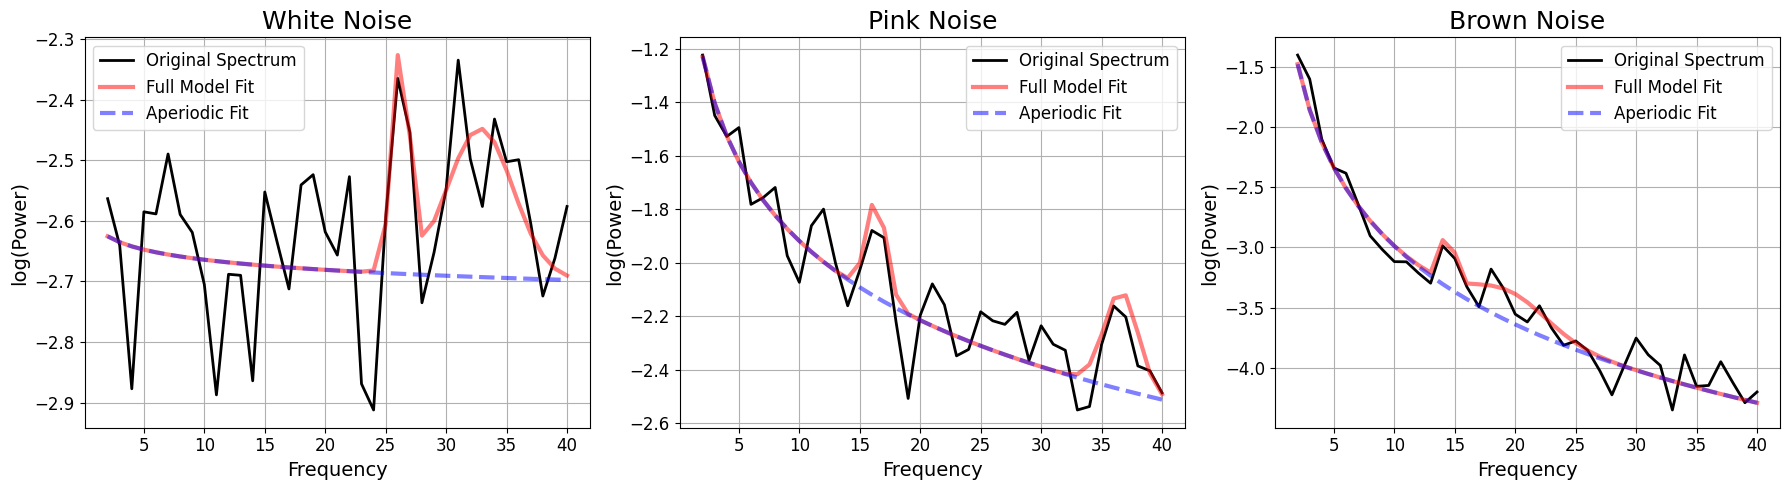

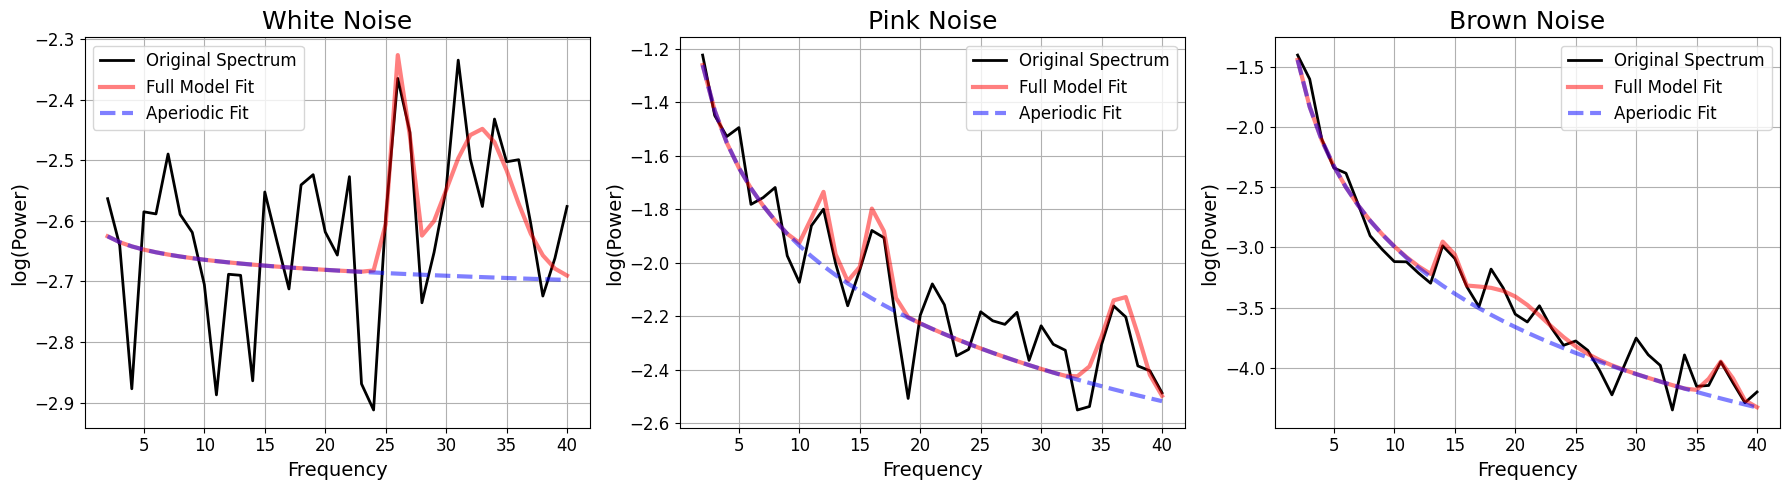

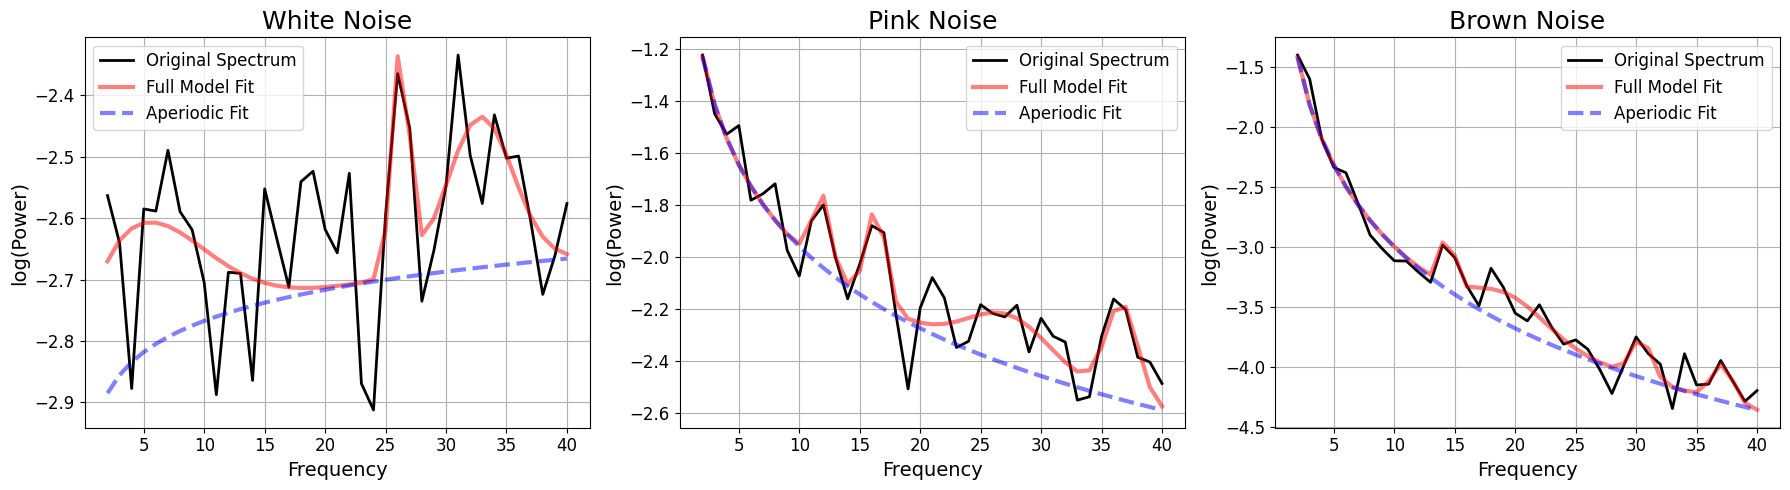

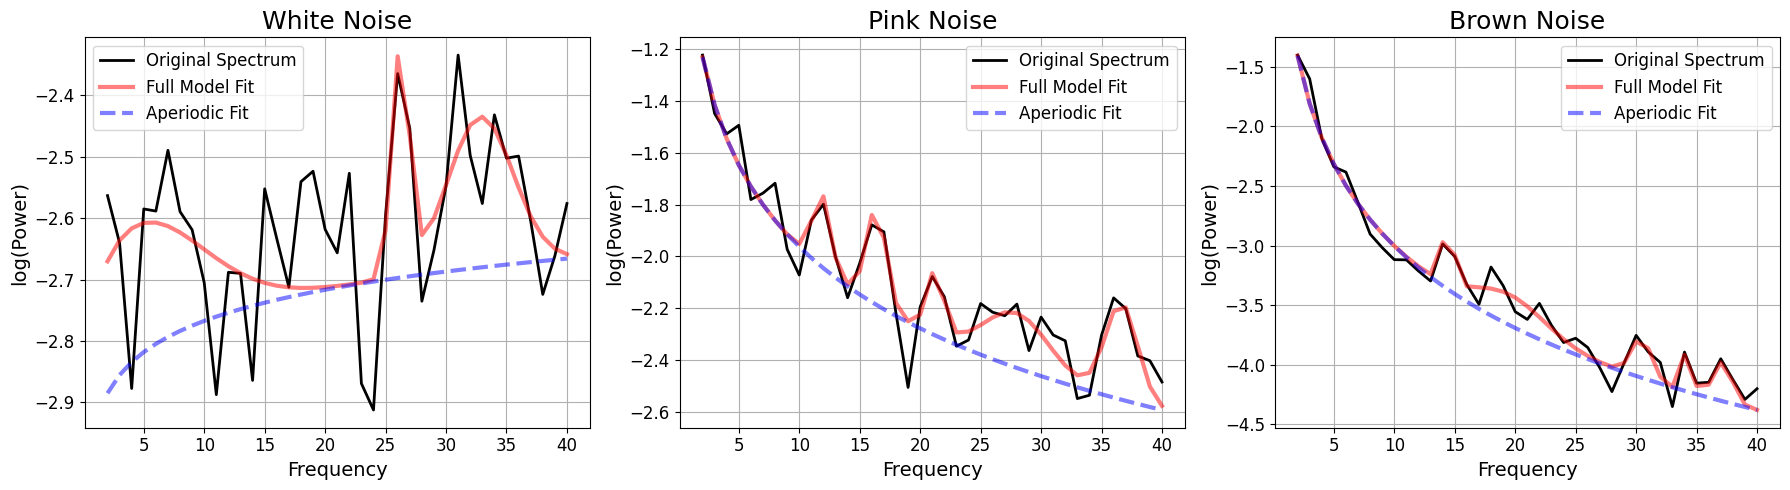

In [110]:
# Max peaks

# Initialise and fit Spectral Modelto the power spectra
for max_n_peaks in range (1, 6, 1):
    fm_w = SpectralModel(max_n_peaks=max_n_peaks)
    fm_p = SpectralModel(max_n_peaks=max_n_peaks)
    fm_b = SpectralModel(max_n_peaks=max_n_peaks)
    freq_range = [2, 40]
    fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))
    fm_w.report(w_freqs, w_powers, freq_range, title = "White Noise", ax=ax1)
    fm_p.report(p_freqs, p_powers, freq_range, title = "Pink Noise", ax=ax2)
    fm_b.report(b_freqs, b_powers, freq_range, title = "Brown Noise", ax=ax3)

#### Peak Threshold


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

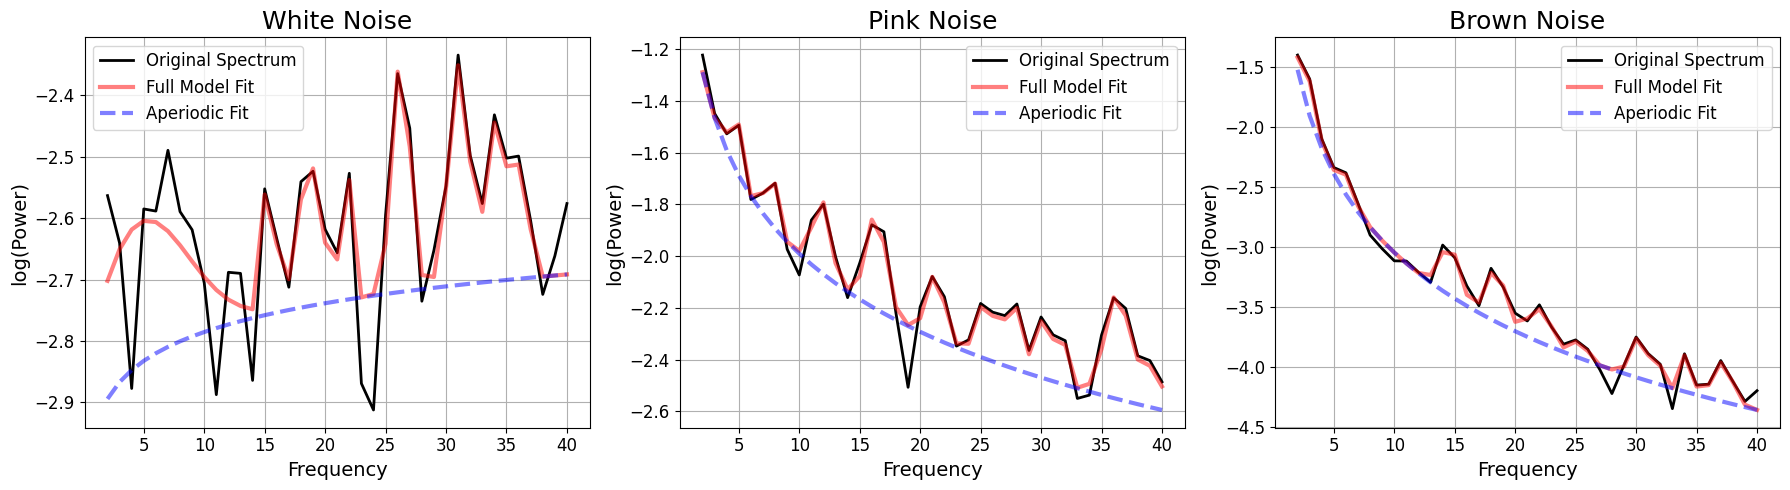

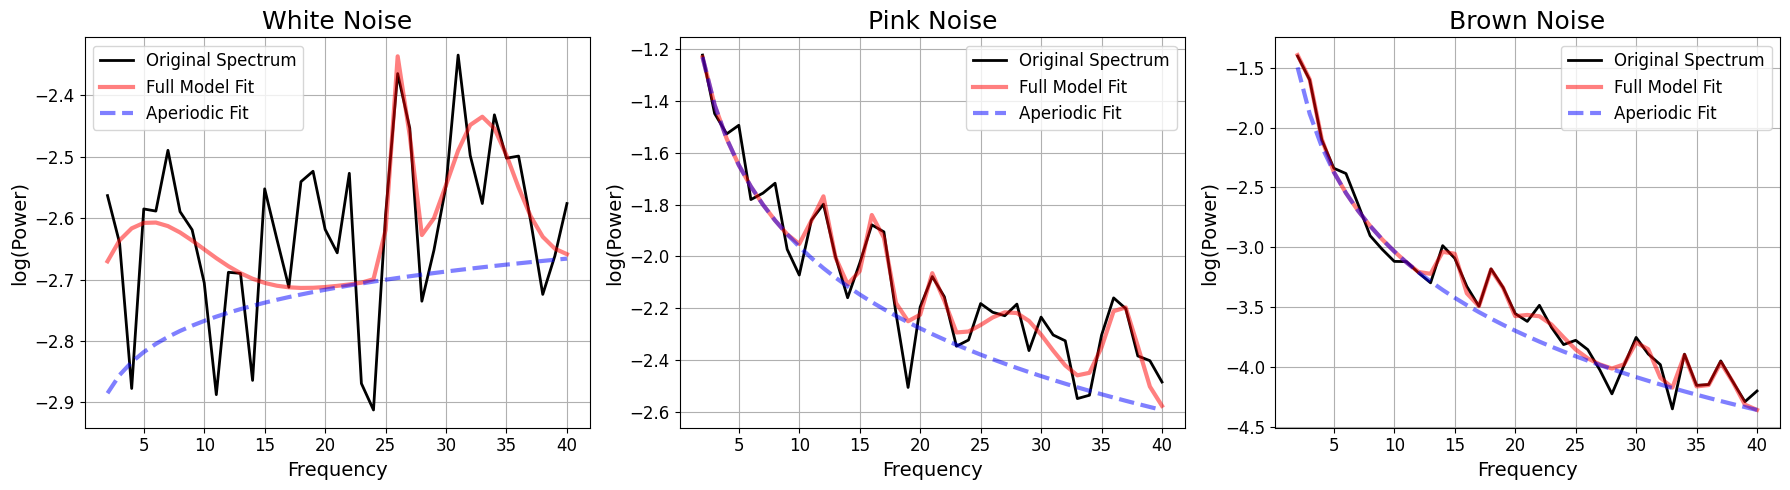

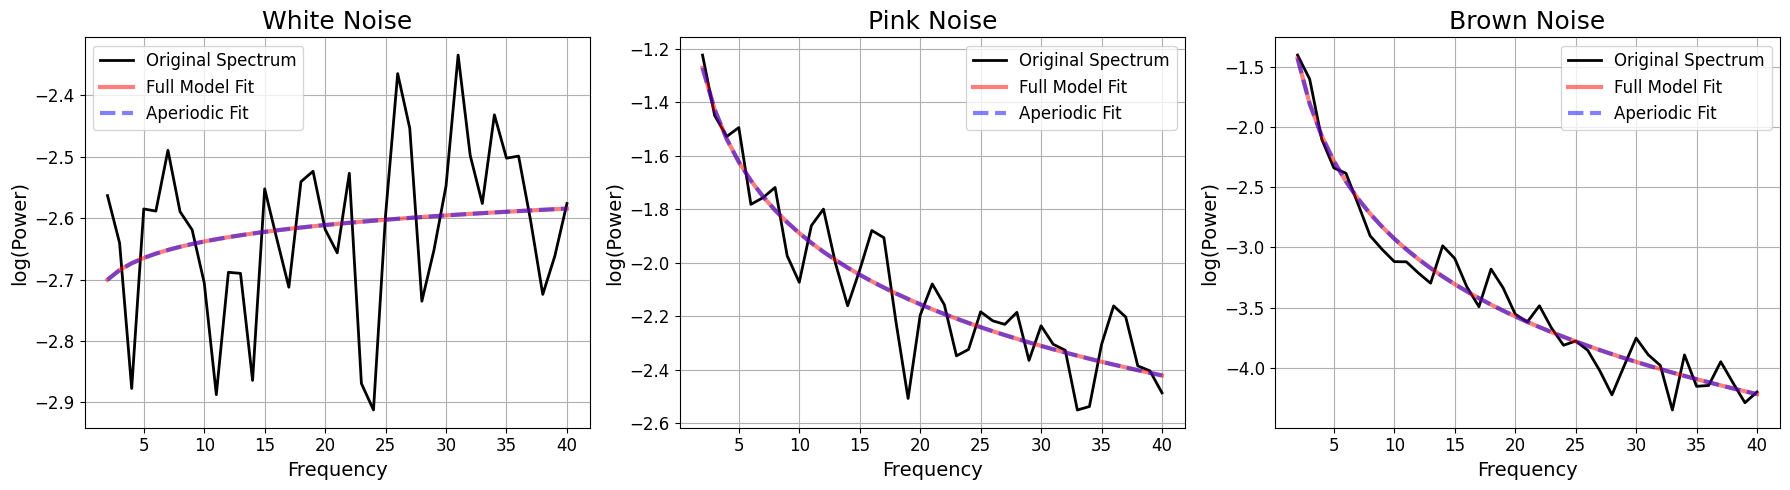

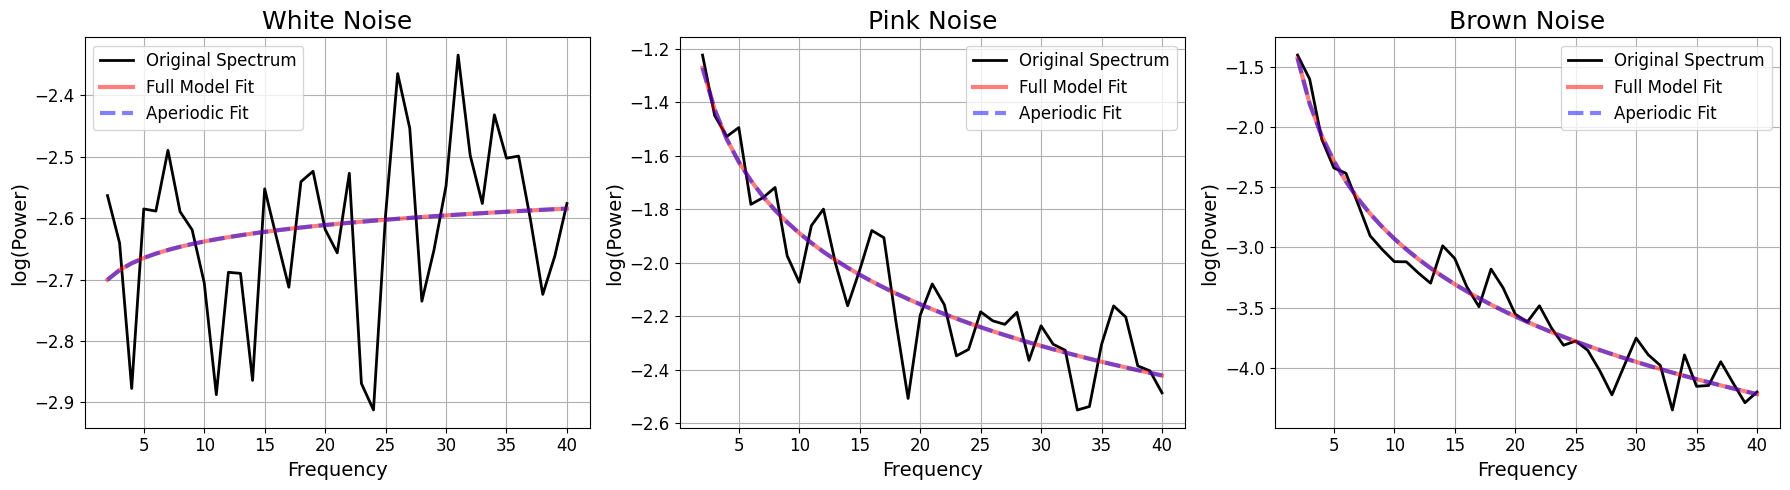

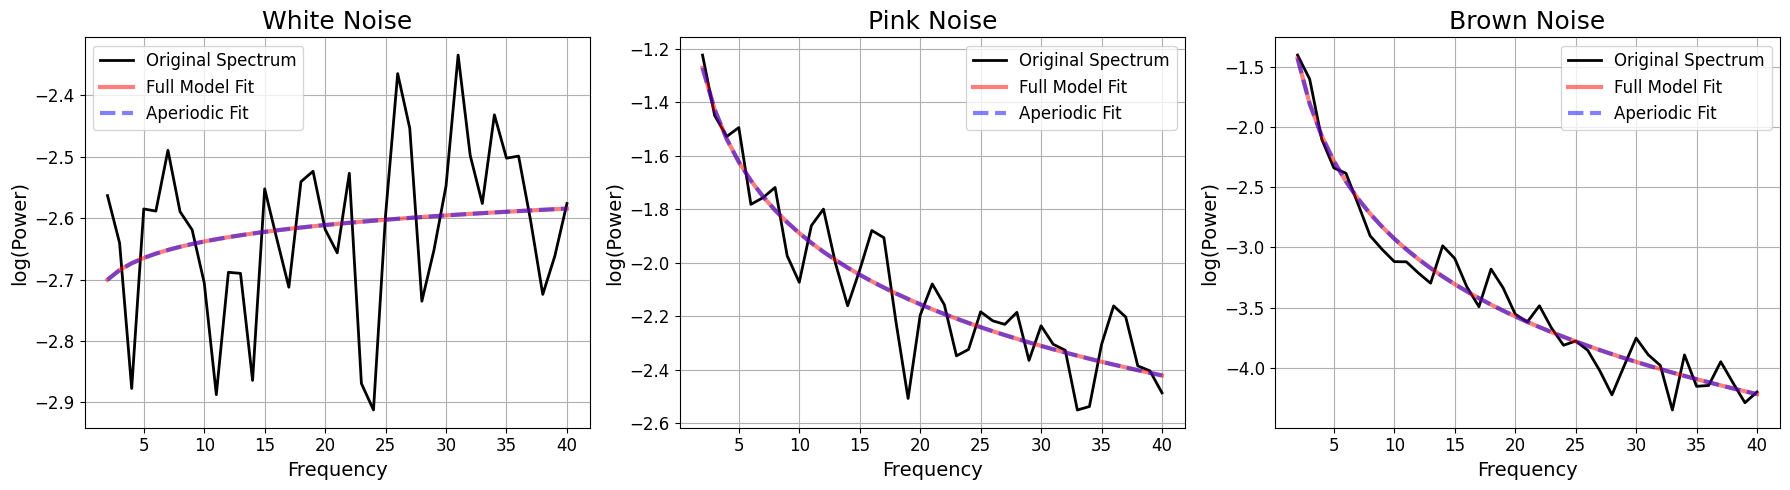

In [111]:
# Peak threshold

# Initialise and fit Spectral Modelto the power spectra
for peak_threshold in range (1, 6, 1):
    fm_w = SpectralModel(peak_threshold=peak_threshold)
    fm_p = SpectralModel(peak_threshold=peak_threshold)
    fm_b = SpectralModel(peak_threshold=peak_threshold)
    freq_range = [2, 40]
    fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))
    fm_w.report(w_freqs, w_powers, freq_range, title = "White Noise", ax=ax1)
    fm_p.report(p_freqs, p_powers, freq_range, title = "Pink Noise", ax=ax2)
    fm_b.report(b_freqs, b_powers, freq_range, title = "Brown Noise", ax=ax3)

## Sim Manipulations

- What happens / changes if you add an oscillation to the simulated time series?
- How many peaks can you add before the model fitting gets weird? How does this interact with model settings?

### Simulation settings

In [10]:
# Define simulation settings
n_seconds = 7
s_rate = 1000

times = create_times(n_seconds, s_rate)
n_points = len(times)

### Adding oscillations

#### Adding oscillations to white noise


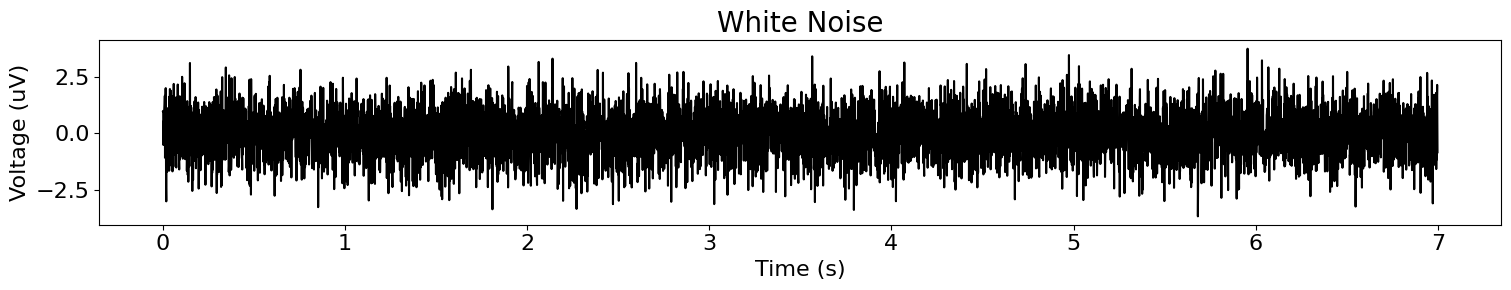

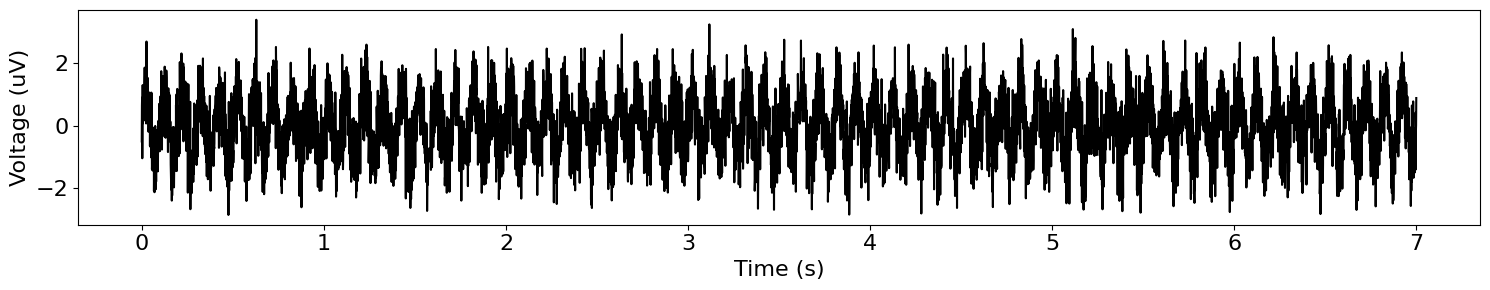

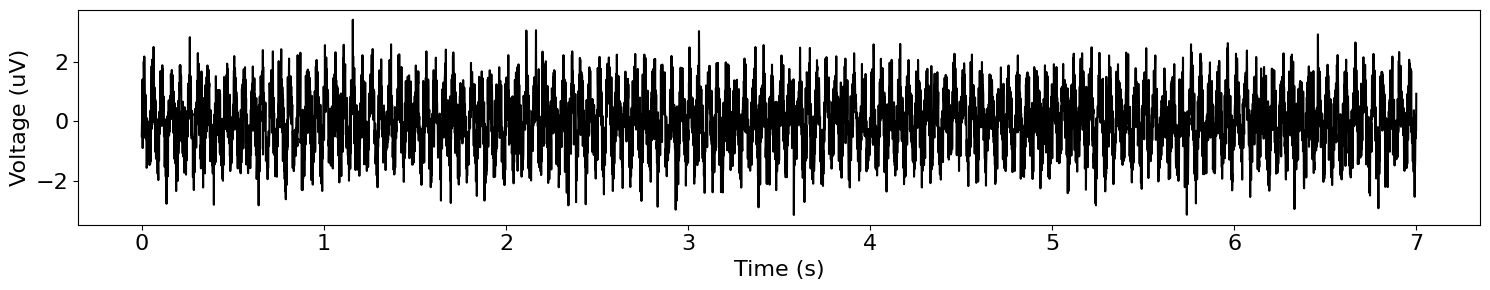

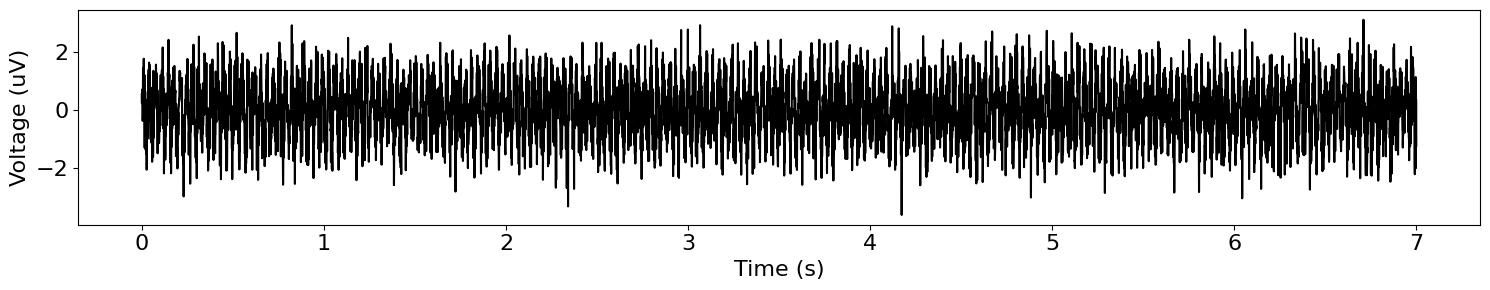

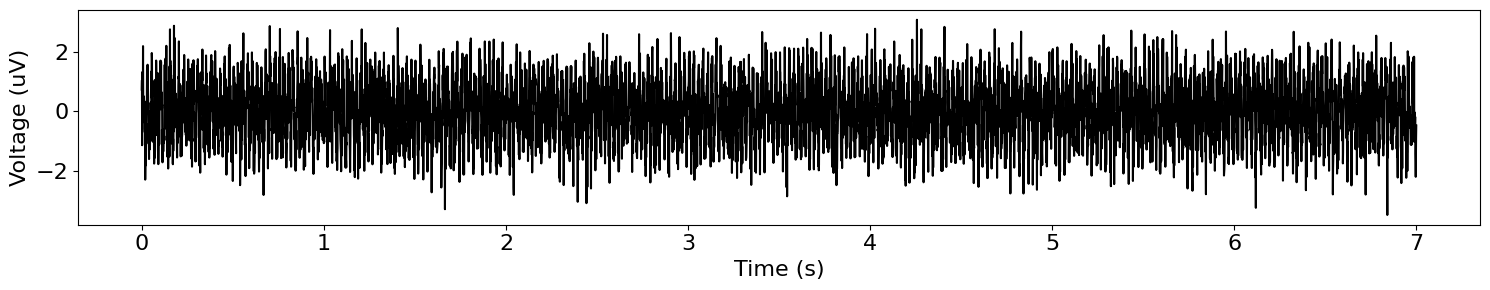

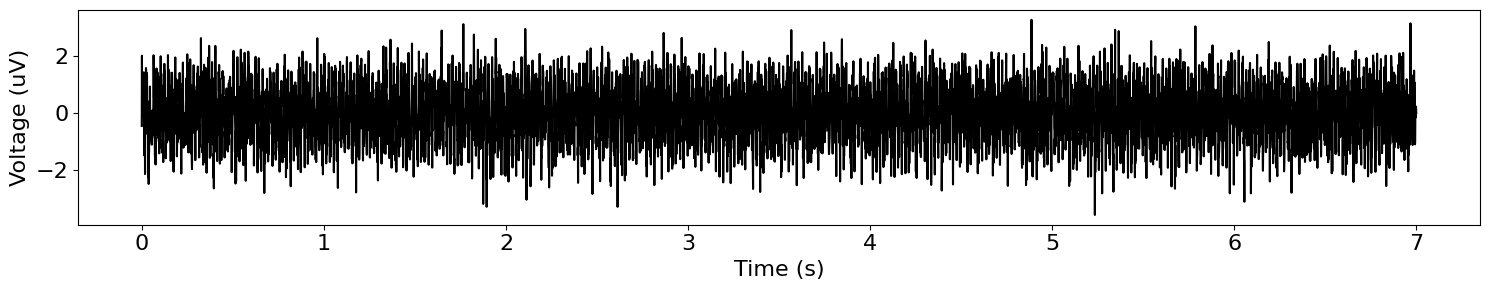

In [128]:
# White noise time series
white_signal = np.random.normal(0, 1, n_points)
plot_time_series (times, white_signal, title = "White Noise")

# Adding oscillations to white noise
for freq in range (10, 51, 10):
    components = {
        'sim_oscillation' : {'freq' : freq},
        'sim_powerlaw' : {'exponent' : 0},
    }

    sig = sim_combined(n_seconds, s_rate, components)

    plot_time_series(times, sig)

#### Adding oscillations to pink noise


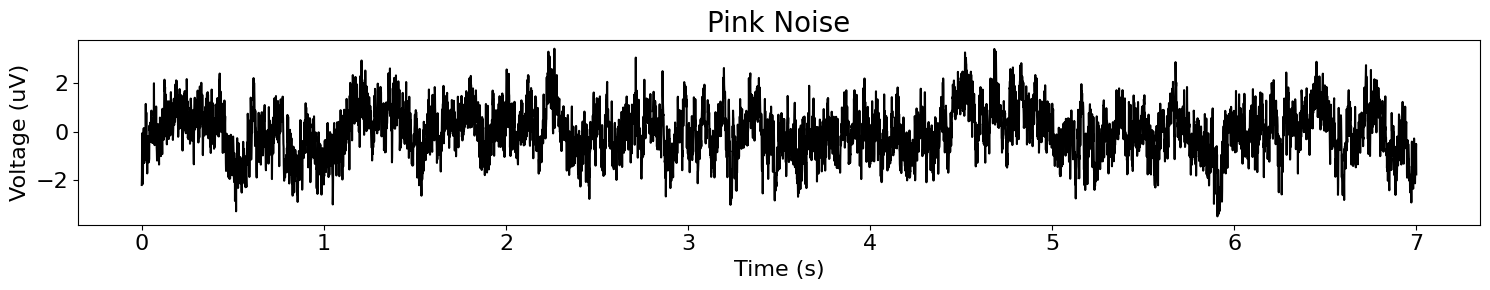

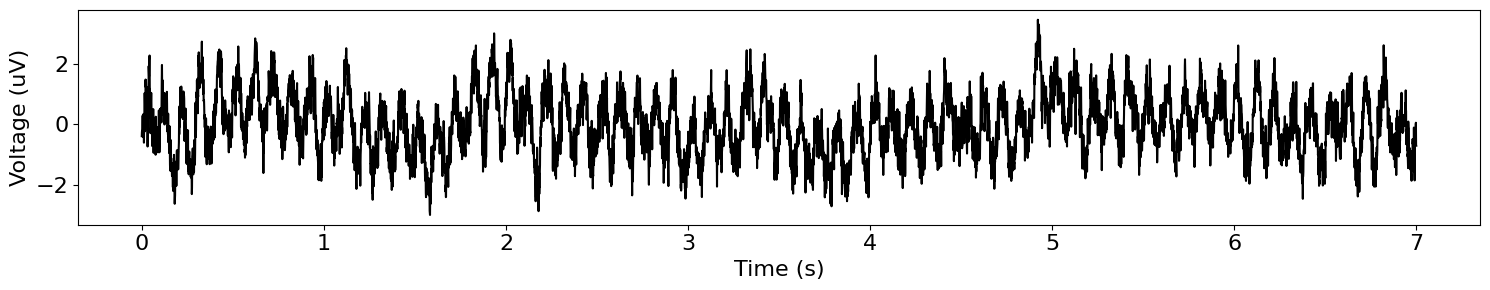

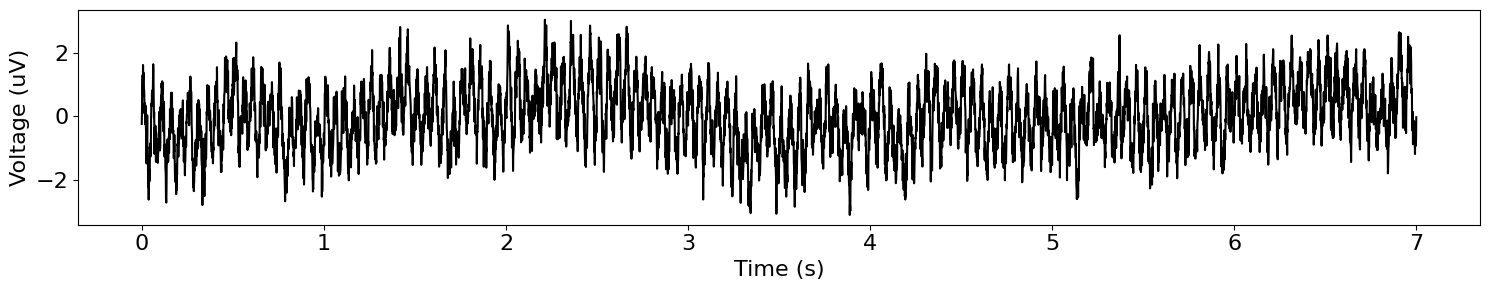

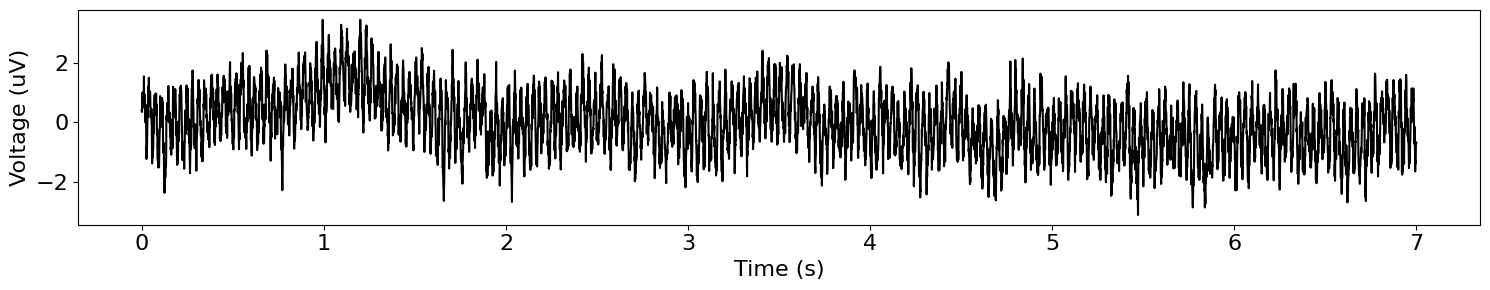

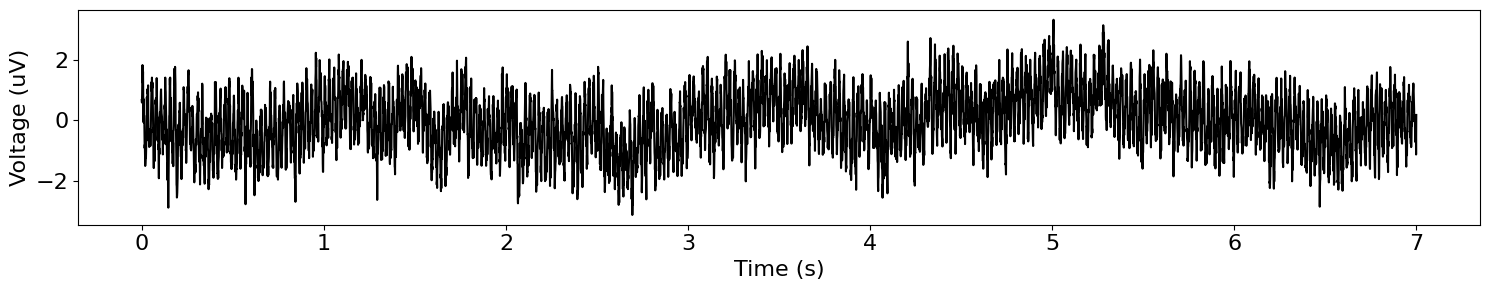

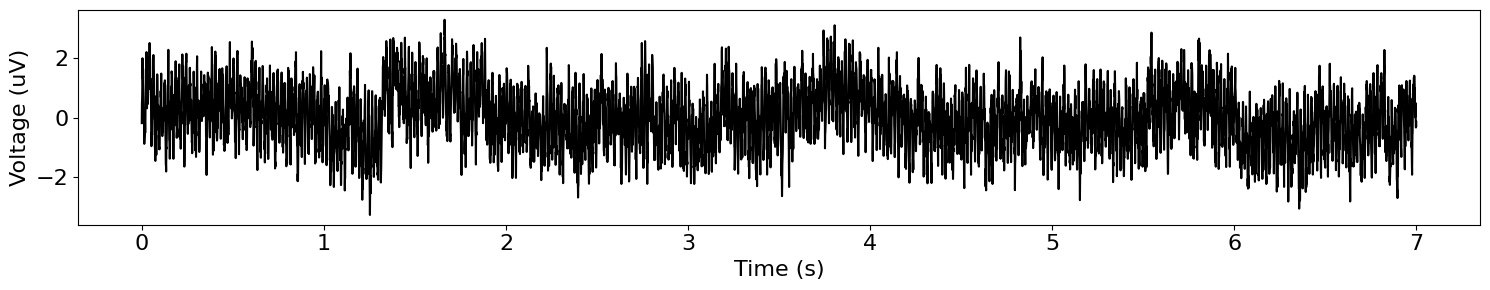

In [130]:
# Pink noise time series
pink_signal = sim_powerlaw(n_seconds, s_rate, exponent=-1)
plot_time_series (times, pink_signal, title = "Pink Noise")

# Adding oscillations to pink noise
for freq in range (10, 51, 10):
    components = {
        'sim_oscillation' : {'freq' : freq},
        'sim_powerlaw' : {'exponent' : -1},
    }

    sig = sim_combined(n_seconds, s_rate, components)

    plot_time_series(times, sig)

#### Adding oscillations to brown noise


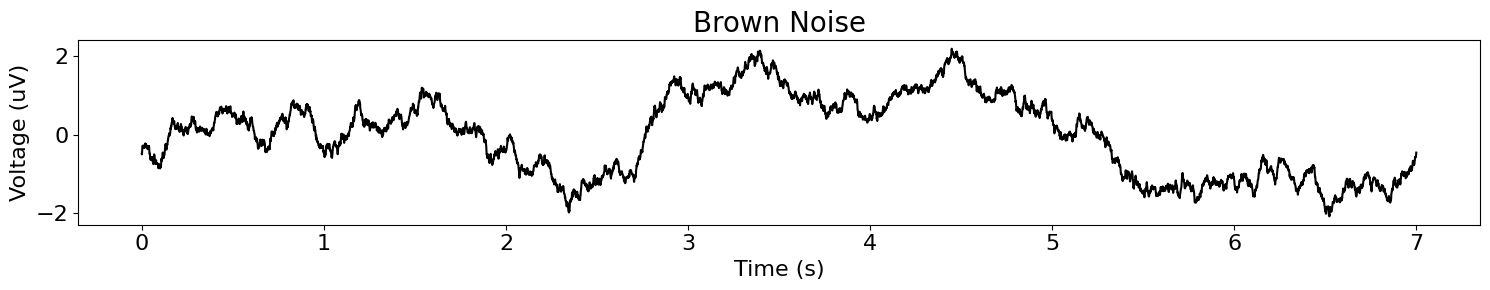

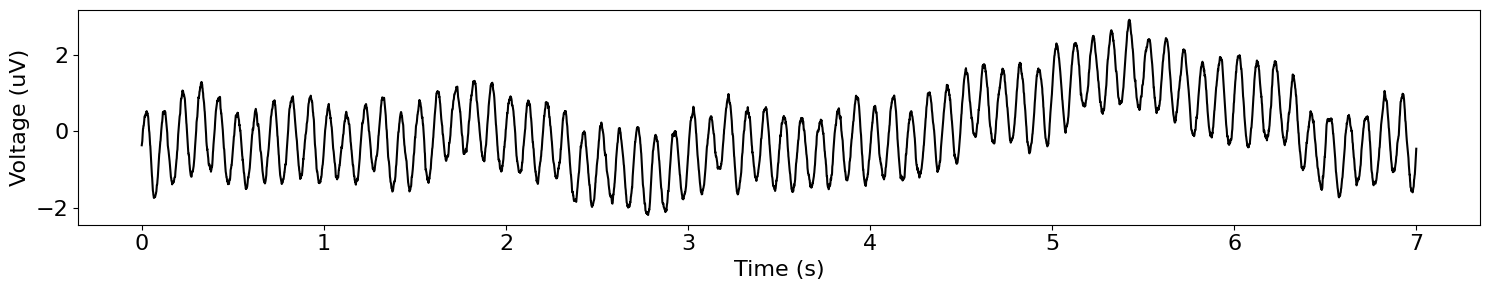

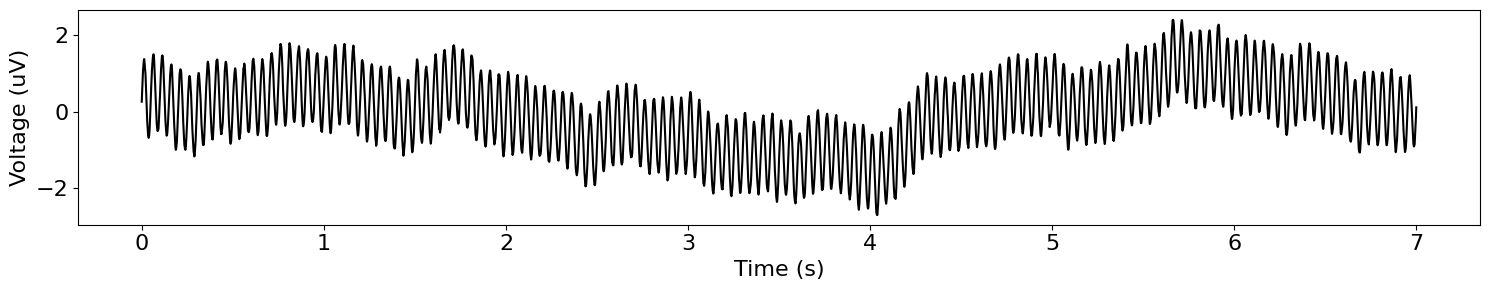

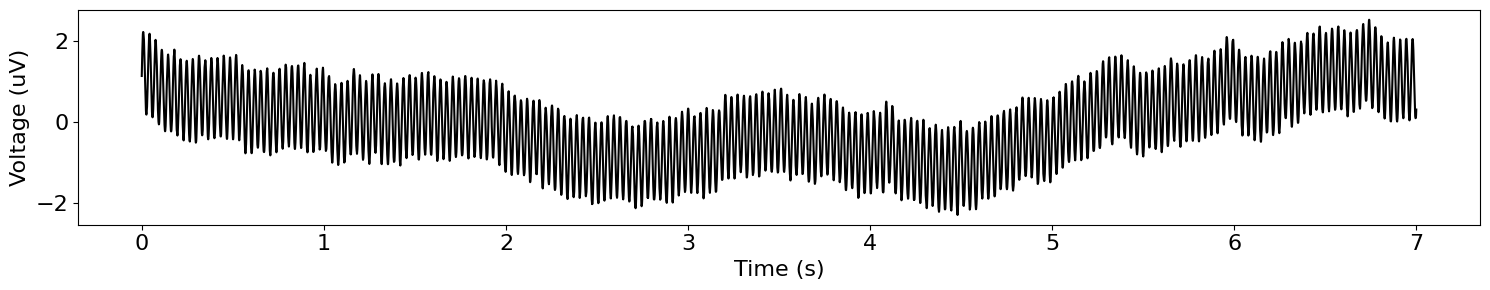

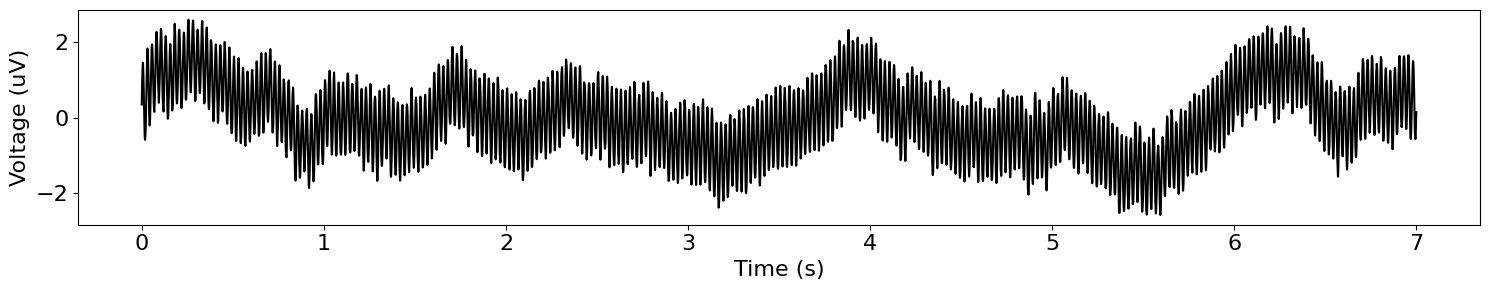

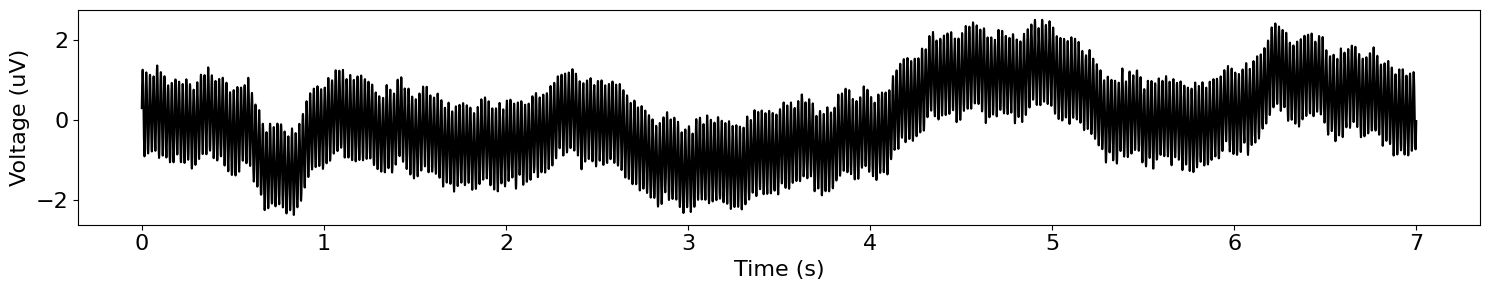

In [132]:
# Brown noise time series
brown_signal = sim_powerlaw(n_seconds, s_rate, exponent=-2)
plot_time_series (times, brown_signal, title = "Brown Noise")

# Adding oscillations to brown noise
for freq in range (10, 51, 10):
    components = {
        'sim_oscillation' : {'freq' : freq},
        'sim_powerlaw' : {'exponent' : -2},
    }

    sig = sim_combined(n_seconds, s_rate, components)

    plot_time_series(times, sig)

### Adding peaks


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

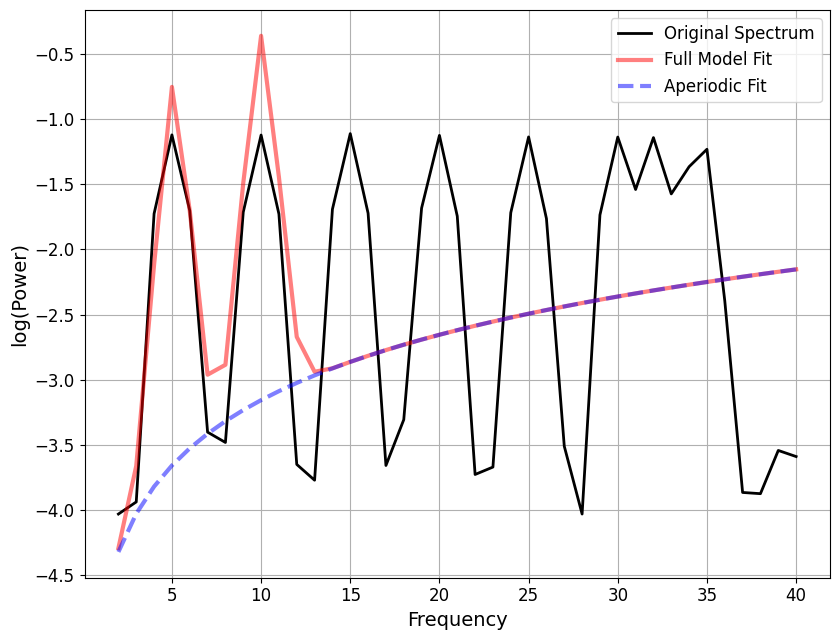

In [17]:
# Adding oscillations increasing numbers of peaks to white noise

components = {
        'sim_oscillation': [{'freq' : 5}, {'freq' : 10}, {'freq' : 15}, {'freq' : 20}, {'freq' : 25}, {'freq' : 30}, {'freq' : 33}, {'freq' : 35}],
        'sim_powerlaw' : {'exponent' : 0},
    }


sig = sim_combined(n_seconds, s_rate, components)

com_freqs, com_powers = compute_spectrum_welch(sig, s_rate)
    
fm_com = SpectralModel()
freq_range = [2, 40]
fm_com.report(com_freqs, com_powers, freq_range)
    


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

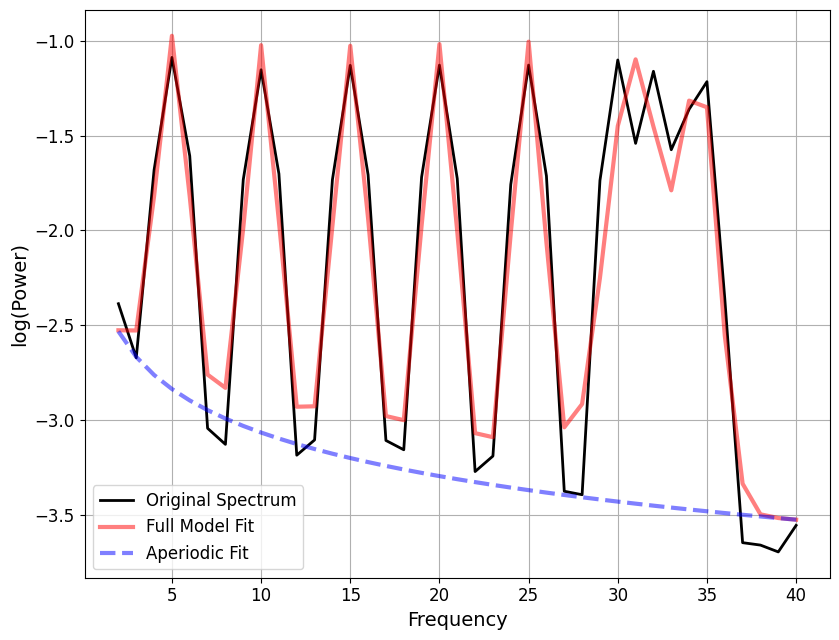

In [20]:
# Adding oscillations increasing numbers of peaks to pink noise

components = {
        'sim_oscillation': [{'freq' : 5}, {'freq' : 10}, {'freq' : 15}, {'freq' : 20}, {'freq' : 25}, {'freq' : 30}, {'freq' : 33}, {'freq' : 35}],
        'sim_powerlaw' : {'exponent' : -1},
    }


sig = sim_combined(n_seconds, s_rate, components)

com_freqs, com_powers = compute_spectrum_welch(sig, s_rate)
    
fm_com = SpectralModel()
freq_range = [2, 40]
fm_com.report(com_freqs, com_powers, freq_range)
    


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

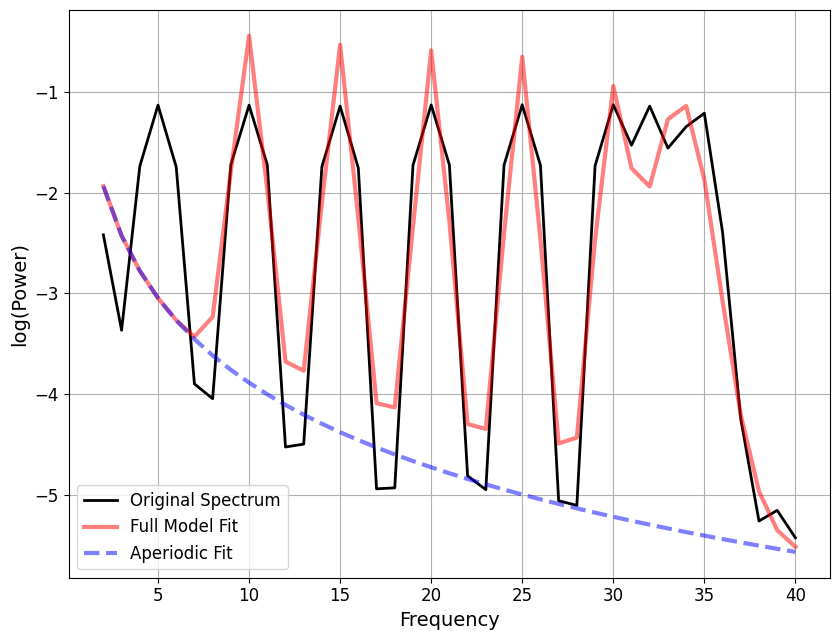

In [21]:
# Adding oscillations increasing numbers of peaks to brown noise

components = {
        'sim_oscillation': [{'freq' : 5}, {'freq' : 10}, {'freq' : 15}, {'freq' : 20}, {'freq' : 25}, {'freq' : 30}, {'freq' : 33}, {'freq' : 35}],
        'sim_powerlaw' : {'exponent' : -2},
    }


sig = sim_combined(n_seconds, s_rate, components)

com_freqs, com_powers = compute_spectrum_welch(sig, s_rate)
    
fm_com = SpectralModel()
freq_range = [2, 40]
fm_com.report(com_freqs, com_powers, freq_range)
    

## Sim Combinations

- For the {white, pink, brown} simulations, if you average together the time series, compute a power spectra and fit a spectral model, what is the resultant exponent? How does it relate to the simulated value(s)
- If you average together the power spectra and fit a spectral model, what is the resultant exponent? How does it relate to the simulated value(s)

- For a given exponent, if you simulate M versions, and fit them all, what is the distribution of fit values (aka how variable is it). How does this relate to different simulation & fitting parameters?

### Simulation settings

In [5]:
# Define simulation settings
n_seconds = 8
s_rate = 900

times = create_times(n_seconds, s_rate)
n_points = len(times)

### White, pink and brown noise combined - time series


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

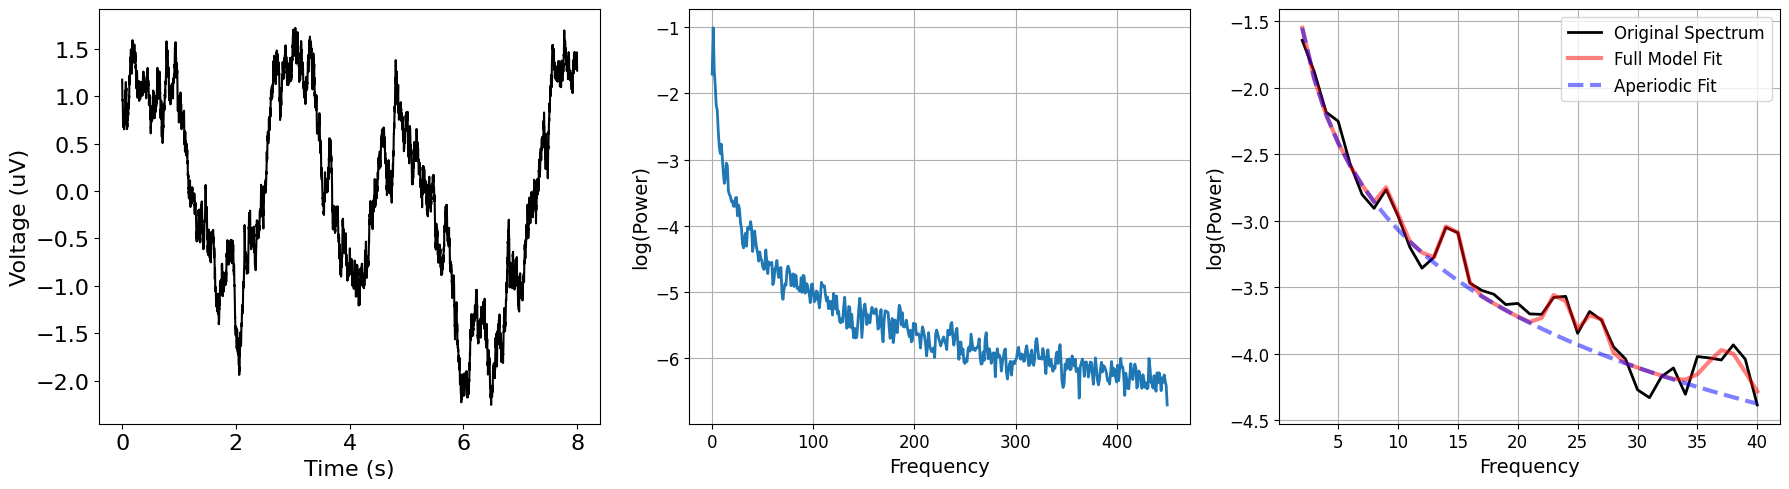

In [13]:
components = {
        'sim_powerlaw' : {'exponent' : 0},
    'sim_powerlaw' : {'exponent' : -1},
    'sim_powerlaw' : {'exponent' : -2},
}

sig = sim_combined(n_seconds, s_rate, components)

fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(18,5))

plot_time_series(times, sig, ax=ax1)

freqs, powers = compute_spectrum_welch(sig, s_rate)
plot_spectra(freqs, powers, log_powers=True, ax=ax2)

fm = SpectralModel()
freq_range = [2, 40]
fm.report(freqs, powers, freq_range, ax=ax3)

**Comments**
- Exponent most closely aligns with Brown Noise
- Visually also closely resemebles brown noise in shape
- However, it loses power in the higher frequencies less quickly. In earlier simulations, when looking at the PSD, the log power by 250Hz is between -6 and -7 however here it is between -5 and -6

### White, pink and brown noise combined - power spectra


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

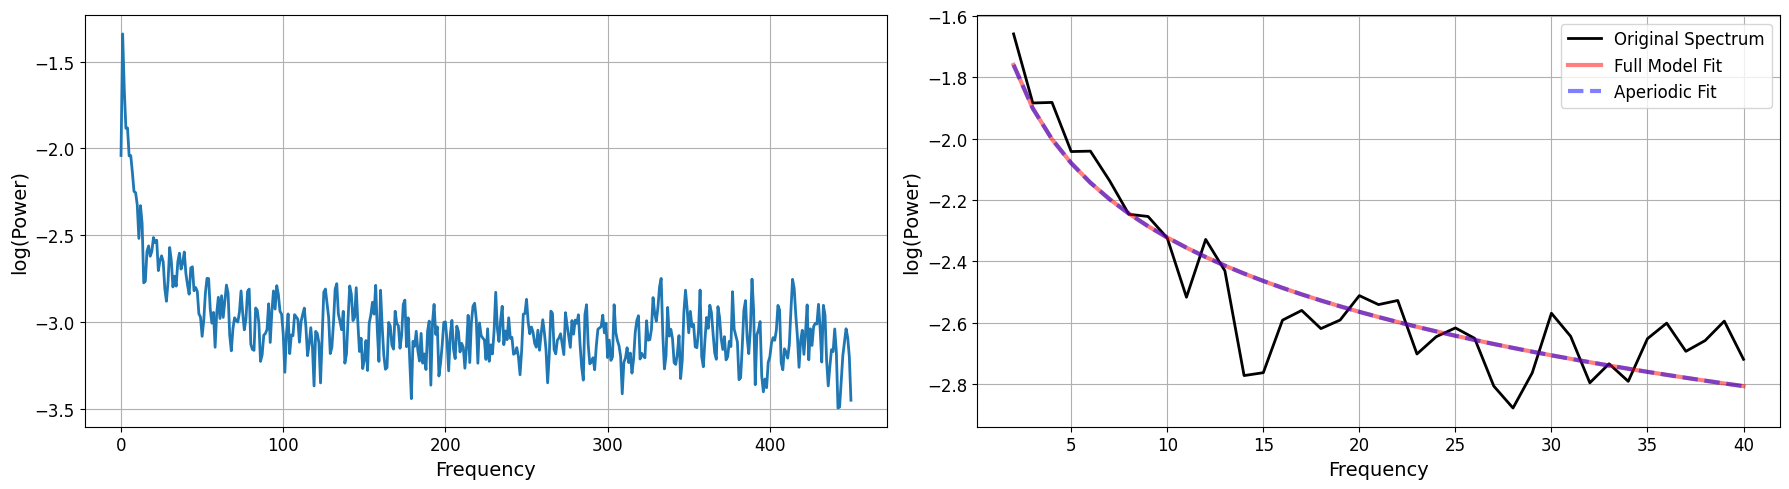

In [28]:
# Simulate signals
white_signal = np.random.normal(0, 1, n_points)
pink_signal = sim_powerlaw(n_seconds, s_rate, exponent=-1)
brown_signal = sim_powerlaw(n_seconds, s_rate, exponent=-2)

# Compute individual power spectra
w_freqs, w_powers = compute_spectrum_welch(white_signal, s_rate)
p_freqs, p_powers = compute_spectrum_welch(pink_signal, s_rate)
b_freqs, b_powers = compute_spectrum_welch(brown_signal, s_rate)

freqs_stack = np.array([w_freqs, p_freqs, b_freqs])
powers_stack = np.array([w_powers, p_powers, b_powers])

avg_freqs = np.mean(freqs_stack, axis=0)
avg_powers = np.mean(powers_stack, axis=0)

fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(18,5))

# Plot power spectra
plot_spectra(avg_freqs, avg_powers, log_powers=True, ax=ax1)

#Plot Spectral Model
fm = SpectralModel()
freq_range = [2,40]
fm.report(avg_freqs, avg_powers, freq_range, ax=ax2)

**Comments**
- Exponent most closely reflects that of pink noise

## Potential Extensions

- How do the measures above relate to different measures (e.g. band power, ratio, etc)
- How do these explorations across gradients (simulated spatial patterns, mimicking electrode-to-electrode variance)